# ============================================
# 1. DATA LOADING & EDA
# ============================================


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (26).zip to archive (26).zip


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (27).zip to archive (27).zip


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (28).zip to archive (28).zip


In [ ]:
import zipfile
import os

# Replace with your file names
zip_files = ["archive (26).zip", "archive (27).zip", "archive (28).zip"]

for z in zip_files:
    with zipfile.ZipFile(z, 'r') as zip_ref:
        zip_ref.extractall("/content/data")

print("Unzipping done!")

Unzipping done!


In [ ]:
import os

# The zip files were extracted into the /content/data directory
extracted_data_path = "/content/data"

print(f"\nContents of {extracted_data_path}:")
# List up to 10 items in the extracted directory
print("Contents:", os.listdir(extracted_data_path)[:10])


Contents of /content/data:
Contents: ['parkinsons.data', 'spiral', 'wave', 'parkinsons_dataset', 'drawings']


In [ ]:
brain_path = "/content/archive (27).zip"
handwriting_path ="/content/archive (26).zip"
voice_path = "/content/archive (28).zip"

Processing brain data from: /content/data/parkinsons_dataset


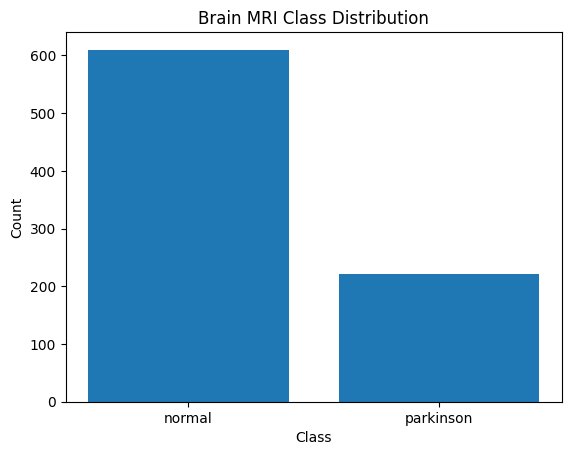

Processing handwriting data from: /content/data/spiral


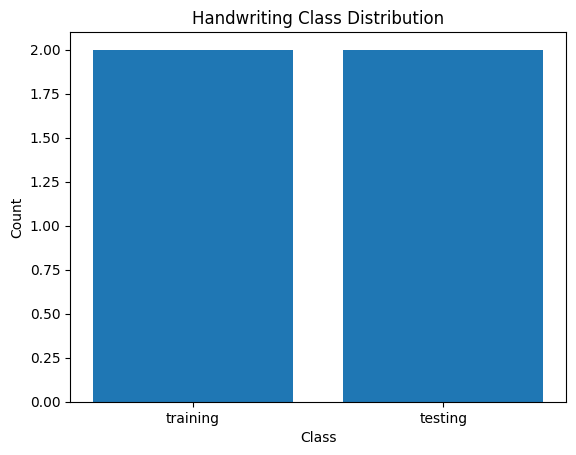

In [ ]:
import matplotlib.pyplot as plt
import os # Ensure os is imported for path operations

def get_class_counts(folder_path):
    counts = {}

    if not os.path.isdir(folder_path):
        print(f"Warning: Path '{folder_path}' is not a directory. Skipping.")
        return counts

    for cls in os.listdir(folder_path):
        cls_path = os.path.join(folder_path, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))

    return counts

def plot_distribution(counts, title):
    if not counts:
        print(f"No data to plot for {title}.")
        return
    plt.figure()
    plt.bar(counts.keys(), counts.values())
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

# Define the base path where data was extracted
extracted_data_base_path = "/content/data"

# Update paths to point to the extracted directories
# Assuming 'parkinsons_dataset' for brain data and 'spiral' for handwriting data
brain_path = os.path.join(extracted_data_base_path, "parkinsons_dataset")
handwriting_path = os.path.join(extracted_data_base_path, "spiral")
voice_path = os.path.join(extracted_data_base_path, "wave") # For completeness, if used later

# Brain
print(f"Processing brain data from: {brain_path}")
brain_counts = get_class_counts(brain_path)
plot_distribution(brain_counts, "Brain MRI Class Distribution")

# Handwriting
print(f"Processing handwriting data from: {handwriting_path}")
hw_counts = get_class_counts(handwriting_path)
plot_distribution(hw_counts, "Handwriting Class Distribution")


In [ ]:
import glob

csv_files = glob.glob(os.path.join(voice_path, "**/*.csv"), recursive=True)
print(csv_files)

[]


In [ ]:
import pandas as pd
import os # Ensure os is imported for path operations

# The previous cell failed to find CSV files because:
# 1. 'voice_path' was set to '/content/data/wave', but 'parkinsons.data' is directly under '/content/data'.
# 2. 'parkinsons.data' has a '.data' extension, not '.csv', so glob.glob('*.csv') missed it.

# Correctly construct the path to the 'parkinsons.data' file.
# 'extracted_data_base_path' is already defined as '/content/data' in the kernel.
voice_data_file_path = os.path.join(extracted_data_base_path, "parkinsons.data")

# Check if the file exists before attempting to read it
if os.path.exists(voice_data_file_path):
    # pd.read_csv can typically handle .data files that are comma-separated
    voice_df = pd.read_csv(voice_data_file_path)
    print("Successfully loaded voice data:")
    print(voice_df.head())
    print(voice_df.columns)
else:
    print(f"Error: Voice data file not found at {voice_data_file_path}")
    print("Please verify the correct path and filename for the voice dataset.")

Successfully loaded voice data:
             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
4           0.00011   0.00655   0.00908     0.01966       0.06425  ...   

   Shimmer:DDA      NHR     HNR  status      RPDE     

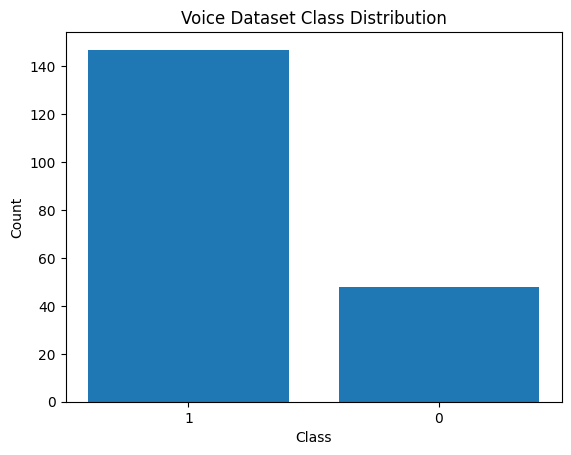

In [ ]:
label_col = "status"

voice_counts = voice_df[label_col].value_counts()

plt.figure()
plt.bar(voice_counts.index.astype(str), voice_counts.values)
plt.title("Voice Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

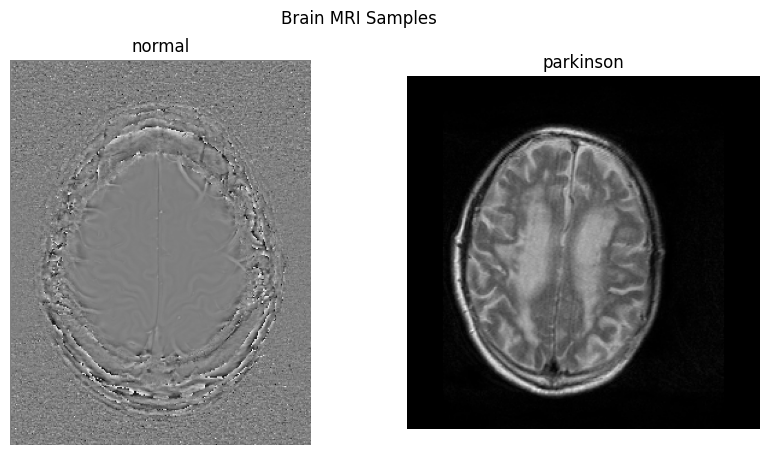

<Figure size 1000x500 with 0 Axes>

In [ ]:
import cv2
import random
import os

def show_samples(folder_path, title):
    # Filter out non-directory entries and limit to first two classes
    classes = [cls for cls in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, cls))][:2]

    plt.figure(figsize=(10,5))

    for i, cls in enumerate(classes):
        cls_path = os.path.join(folder_path, cls)

        # Filter for actual image files based on common extensions
        image_files = [f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]

        if not image_files:
            print(f"Warning: No image files found in {cls_path}. Skipping class {cls}.")
            continue

        img_name = random.choice(image_files)
        img_path = os.path.join(cls_path, img_name)

        img = cv2.imread(img_path)

        if img is None: # Check if image was loaded successfully
            print(f"Warning: Could not read image {img_path}. Skipping this image.")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1,2,i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

# Brain samples
show_samples(brain_path, "Brain MRI Samples")

# Handwriting samples
show_samples(handwriting_path, "Handwriting Samples")

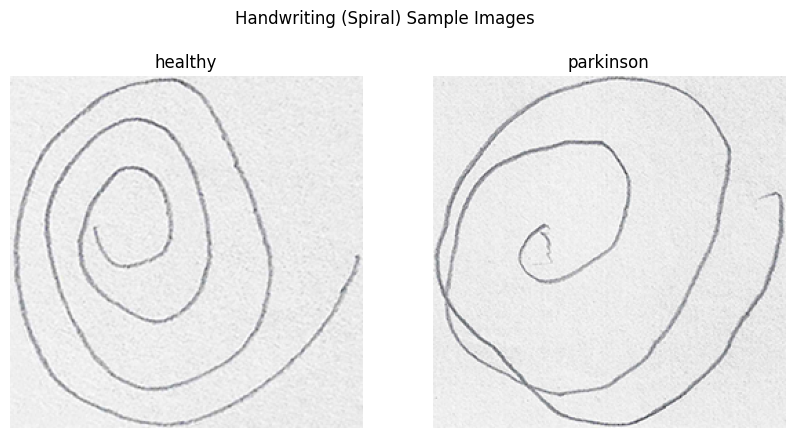

In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

# Path to your spiral folder, using the correct extracted path
base_spiral_path = handwriting_path  # This should be '/content/data/spiral'

train_data_path = os.path.join(base_spiral_path, "training")

# Get class folders (healthy / parkinson) from the training directory
# This assumes the structure is /content/data/spiral/training/healthy and /content/data/spiral/training/parkinson
classes = os.listdir(train_data_path)

plt.figure(figsize=(10,5))

for i, cls in enumerate(classes[:2]):  # take 2 classes, e.g., 'healthy', 'parkinson'
    cls_images_path = os.path.join(train_data_path, cls)

    # Pick random image
    # Ensure to only pick actual image files with common extensions
    image_files = [f for f in os.listdir(cls_images_path) if os.path.isfile(os.path.join(cls_images_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]

    if not image_files:
        print(f"Warning: No image files found in {cls_images_path}. Skipping class {cls}.")
        continue

    img_name = random.choice(image_files)
    img_path = os.path.join(cls_images_path, img_name)

    # Read image
    img = cv2.imread(img_path)

    if img is None: # Check if image was loaded successfully
        print(f"Warning: Could not read image {img_path}. Skipping this image.")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Handwriting (Spiral) Sample Images")
plt.show()

In [ ]:
import librosa
import librosa.display

# Find audio file column
print(voice_df.columns)

Index(['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')


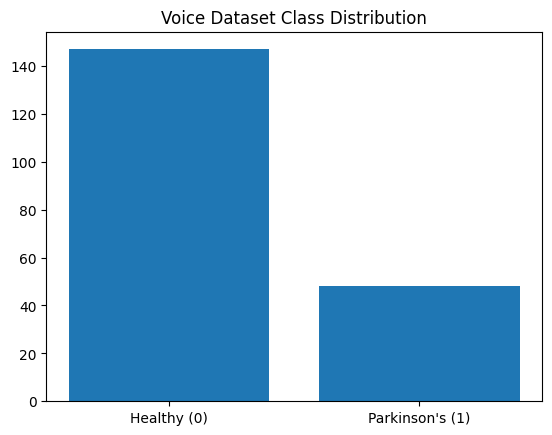

In [ ]:
import matplotlib.pyplot as plt

counts = voice_df["status"].value_counts()

plt.bar(["Healthy (0)", "Parkinson's (1)"], counts.values)
plt.title("Voice Dataset Class Distribution")
plt.show()

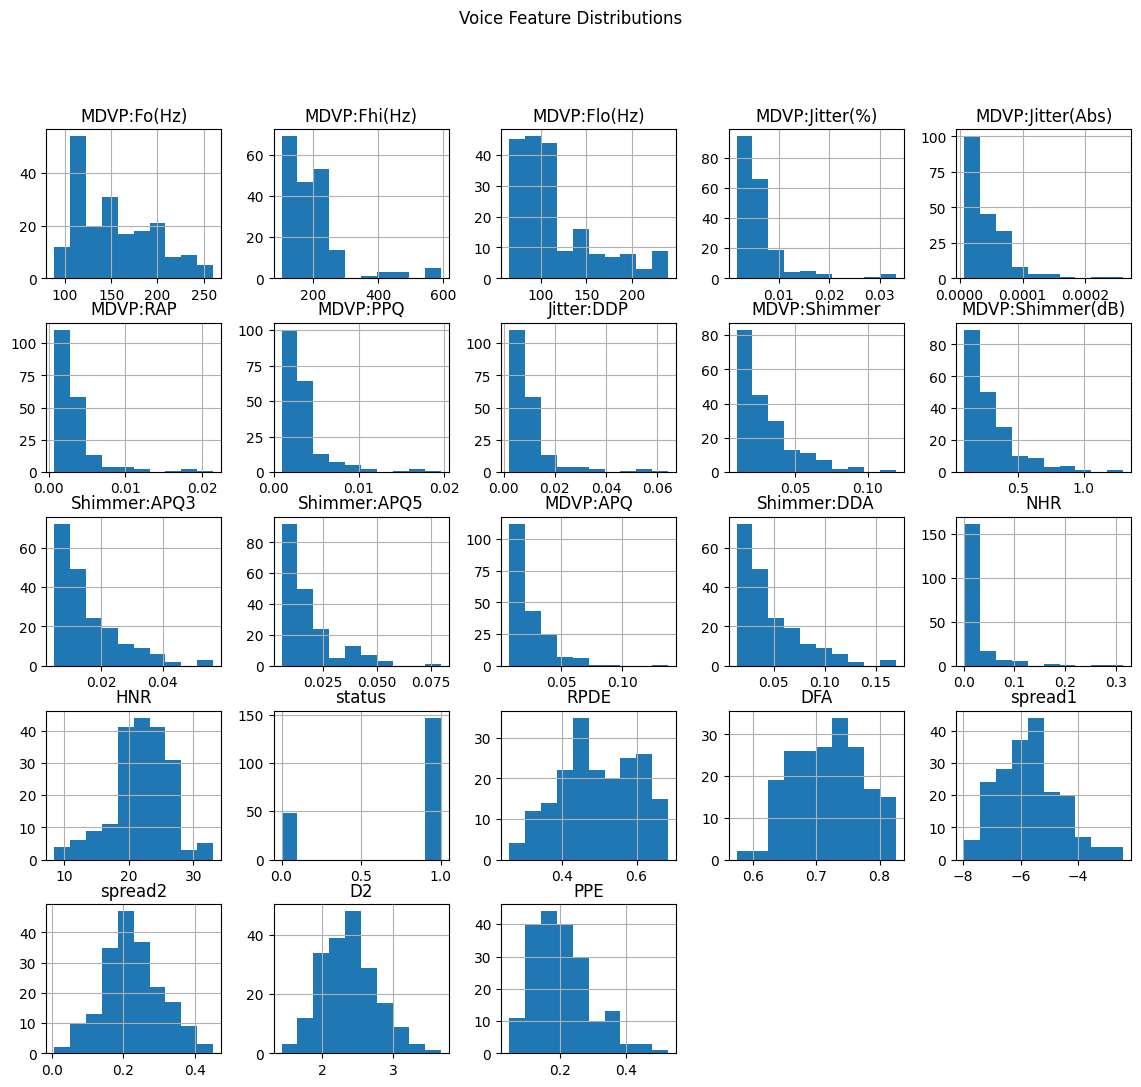

In [ ]:
voice_df.drop(columns=["name"], errors="ignore").hist(figsize=(14,12))
plt.suptitle("Voice Feature Distributions")
plt.show()

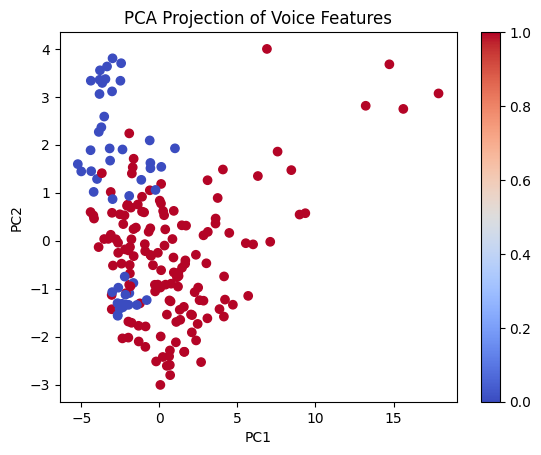

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = voice_df.drop(columns=["status", "name"], errors="ignore")
y = voice_df["status"]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="coolwarm")
plt.title("PCA Projection of Voice Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.show()

In [ ]:
import subprocess, sys
for pkg in ["torch","scikit-learn","imbalanced-learn","matplotlib","seaborn","umap-learn"]:
    subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.optim.swa_utils import AveragedModel, SWALR

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, f1_score,
                              roc_curve, precision_recall_fscore_support)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE, BorderlineSMOTE

import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, random, os

warnings.filterwarnings("ignore")
plt.rcParams.update({"font.family":"DejaVu Sans","figure.dpi":150})
os.makedirs("figures", exist_ok=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}  |  PyTorch: {torch.__version__}")

PALETTE = {
    "Brain":"#3B82F6","Handwriting":"#10B981","Voice":"#F59E0B",
    "Healthy":"#6366F1","Disease":"#EF4444",
    "Train":"#3B82F6","Val":"#F59E0B",
}

Device: cuda  |  PyTorch: 2.10.0+cu128


# ============================================
# 2. FEATURE EXTRACTION
# ============================================

In [ ]:
DATA_DIR = "/content/"

X_brain = np.load(DATA_DIR+"brain_features (1).npy",       allow_pickle=True).astype(np.float32)
y_brain = np.load(DATA_DIR+"brain_labels.npy",             allow_pickle=True).astype(np.int64)
X_hw    = np.load(DATA_DIR+"handwriting_features (1).npy", allow_pickle=True).astype(np.float32)
y_hw    = np.load(DATA_DIR+"handwriting_labels.npy",       allow_pickle=True).astype(np.int64)
X_voice = np.load(DATA_DIR+"voice_features.npy",           allow_pickle=True).astype(np.float32)
y_voice = np.load(DATA_DIR+"voice_labels.npy",             allow_pickle=True).astype(np.int64)

print(f"Brain  {X_brain.shape}  classes={np.bincount(y_brain)}")
print(f"HW     {X_hw.shape}    classes={np.bincount(y_hw)}")
print(f"Voice  {X_voice.shape}   classes={np.bincount(y_voice)}")

Brain  (676, 1664)  classes=[516 160]
HW     (653, 512)    classes=[332 321]
Voice  (195, 22)   classes=[ 48 147]


In [ ]:
def engineer_voice_features(X):
    """
    Creates enriched feature set from raw 22-d voice features:
    - Original 22 features
    - Squared terms (22) — captures nonlinear variance patterns
    - Top-pair interactions (selected by correlation strength)
    Final dim: 22 + 22 + top_k_interactions
    """
    X2  = X ** 2                          # squared (energy-like terms)
    # interactions of top correlated pairs  (feat 18,21,12,19,4,5,6,3)
    top = [18, 21, 12, 19, 4, 5, 6, 3]
    pairs = []
    for i in range(len(top)):
        for j in range(i+1, len(top)):
            pairs.append((X[:, top[i]] * X[:, top[j]]).reshape(-1, 1))
    X_inter = np.hstack(pairs)            # 28 interaction terms
    return np.hstack([X, X2, X_inter]).astype(np.float32)

X_voice_eng = engineer_voice_features(X_voice)
DIM_V_ENG   = X_voice_eng.shape[1]
print(f"Voice engineered features: {X_voice.shape[1]} → {DIM_V_ENG}")

Voice engineered features: 22 → 72


In [ ]:
def split3(X, y, val=0.20, test=0.20):
    X_tv,X_te,y_tv,y_te = train_test_split(X,y,test_size=test,stratify=y,random_state=SEED)
    X_tr,X_va,y_tr,y_va = train_test_split(X_tv,y_tv,test_size=val/(1-test),
                                            stratify=y_tv,random_state=SEED)
    return X_tr,X_va,X_te,y_tr,y_va,y_te

Xb_tr,Xb_va,Xb_te, yb_tr,yb_va,yb_te = split3(X_brain,  y_brain)
Xh_tr,Xh_va,Xh_te, yh_tr,yh_va,yh_te = split3(X_hw,     y_hw)
# Split on engineered voice
Xv_tr,Xv_va,Xv_te, yv_tr,yv_va,yv_te = split3(X_voice_eng, y_voice)

print(f"Brain  train={len(yb_tr)} val={len(yb_va)} test={len(yb_te)}")
print(f"HW     train={len(yh_tr)} val={len(yh_va)} test={len(yh_te)}")
print(f"Voice  train={len(yv_tr)} val={len(yv_va)} test={len(yv_te)}")

Brain  train=405 val=135 test=136
HW     train=391 val=131 test=131
Voice  train=117 val=39 test=39


In [ ]:
class Prep:
    """
    FIX: Voice uses StandardScaler (not Robust) — it is already normalised.
    Brain/HW use RobustScaler for outlier robustness.
    SMOTE with BorderlineSMOTE for voice — better boundary synthesis.
    """
    def __init__(self, pca_dim=None, smote_k=3, scaler_type="robust",
                 smote_type="regular"):
        if scaler_type == "standard":
            self.sc = StandardScaler()
        else:
            self.sc = RobustScaler()
        self.pca       = PCA(n_components=pca_dim, random_state=SEED) if pca_dim else None
        self.smote_k   = smote_k
        self.smote_type = smote_type

    def fit_transform(self, X, y):
        X = self.sc.fit_transform(X).astype(np.float32)
        if self.pca:
            X = self.pca.fit_transform(X).astype(np.float32)
        mc = min(np.bincount(y))
        k  = min(self.smote_k, mc-1)
        if k >= 1:
            if self.smote_type == "borderline":
                sm = BorderlineSMOTE(random_state=SEED, k_neighbors=k, kind="borderline-1")
            else:
                sm = SMOTE(random_state=SEED, k_neighbors=k)
            X, y = sm.fit_resample(X, y)
        return X.astype(np.float32), y.astype(np.int64)

    def transform(self, X):
        X = self.sc.transform(X).astype(np.float32)
        if self.pca:
            X = self.pca.transform(X).astype(np.float32)
        return X.astype(np.float32)

# Brain: PCA 1664→80 (keeps ~95% variance)
pb = Prep(pca_dim=80, smote_k=4, scaler_type="robust")
# HW:    PCA 512→60
ph = Prep(pca_dim=60, smote_k=4, scaler_type="robust")
# Voice: NO PCA (engineered features are already compact), StandardScaler,
#        BorderlineSMOTE for better minority synthesis
pv = Prep(pca_dim=None, smote_k=4, scaler_type="standard", smote_type="borderline")

Xb_tr_p,yb_tr_p = pb.fit_transform(Xb_tr, yb_tr)
Xb_va_p = pb.transform(Xb_va);  Xb_te_p = pb.transform(Xb_te)

Xh_tr_p,yh_tr_p = ph.fit_transform(Xh_tr, yh_tr)
Xh_va_p = ph.transform(Xh_va);  Xh_te_p = ph.transform(Xh_te)

Xv_tr_p,yv_tr_p = pv.fit_transform(Xv_tr, yv_tr)
Xv_va_p = pv.transform(Xv_va);  Xv_te_p = pv.transform(Xv_te)

DIM_B,DIM_H,DIM_V = Xb_tr_p.shape[1], Xh_tr_p.shape[1], Xv_tr_p.shape[1]
print(f"Dims — Brain:{DIM_B}  HW:{DIM_H}  Voice:{DIM_V}")

Dims — Brain:80  HW:60  Voice:72


In [ ]:
def mixup_batch(x, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    xm  = lam*x + (1-lam)*x[idx]
    ya  = F.one_hot(y,     2).float()
    yb_ = F.one_hot(y[idx],2).float()
    return xm, lam*ya + (1-lam)*yb_

# ============================================
# 3. KNOWLEDGE DISTILLATION (KD)
# ============================================

In [ ]:
class RegBlock(nn.Module):
    def __init__(self, i, o, p=0.4):
        super().__init__()
        self.net  = nn.Sequential(nn.Linear(i,o), nn.LayerNorm(o), nn.GELU(), nn.Dropout(p))
        self.proj = nn.Linear(i,o) if i!=o else nn.Identity()
        self.ln   = nn.LayerNorm(o)
    def forward(self, x):
        return F.gelu(self.ln(self.net(x) + self.proj(x)))


class AttentionGate(nn.Module):
    """Lightweight channel attention for voice features."""
    def __init__(self, dim):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(dim, dim//4), nn.ReLU(),
            nn.Linear(dim//4, dim), nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.gate(x)


# Teacher architectures (unchanged — they already work well)
class BrainTeacher(nn.Module):
    def __init__(self, in_dim=80):
        super().__init__()
        self.encoder    = nn.Sequential(RegBlock(in_dim,128,0.5), RegBlock(128,64,0.5))
        self.embed_dim  = 64
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(64,2))
    def forward(self, x):
        e = self.encoder(x); return self.classifier(e), e

class HWTeacher(nn.Module):
    def __init__(self, in_dim=60):
        super().__init__()
        self.encoder    = nn.Sequential(RegBlock(in_dim,96,0.5), RegBlock(96,64,0.5))
        self.embed_dim  = 64
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(64,2))
    def forward(self, x):
        e = self.encoder(x); return self.classifier(e), e


class VoiceStudentV2(nn.Module):
    """
    UPGRADED Student — 3 blocks + attention gate + bottleneck.

    Why deeper for voice (22-d)?
    Voice features have strong nonlinear interactions (shown by corr analysis).
    A 3-layer network with attention can learn the feature interactions that
    simple 2-layer cannot.  Dropout reduced to 0.3 since voice data is smaller
    and we need the model to learn despite fewer samples.
    The proj_head is kept for CCR loss.
    """
    def __init__(self, in_dim, hidden=128, embed_dim=96, num_classes=2, dropout=0.3):
        super().__init__()
        self.encoder = nn.Sequential(
            RegBlock(in_dim, hidden,    dropout),
            AttentionGate(hidden),
            RegBlock(hidden, embed_dim, dropout),
            RegBlock(embed_dim, embed_dim, dropout),
        )
        self.embed_dim  = embed_dim
        self.classifier = nn.Sequential(
            nn.Dropout(0.25),
            nn.Linear(embed_dim, embed_dim//2),
            nn.GELU(),
            nn.Linear(embed_dim//2, num_classes)
        )
        self.proj_head = nn.Sequential(
            nn.Linear(embed_dim, 64), # Changed output dimension to 64
            nn.LayerNorm(64)          # Adjusted LayerNorm dimension
        )

    def forward(self, x):
        e = self.encoder(x)
        return self.classifier(e), e, self.proj_head(e)

def param_count(m): return sum(p.numel() for p in m.parameters())
print(f"BrainTeacher : {param_count(BrainTeacher(DIM_B)):,}")
print(f"HWTeacher    : {param_count(HWTeacher(DIM_H)):,}")
print(f"VoiceStudent : {param_count(VoiceStudentV2(DIM_V)):,}")

BrainTeacher : 38,146
HWTeacher    : 24,898
VoiceStudent : 73,490


In [ ]:
class LabelSmoothCE(nn.Module):
    def __init__(self, s=0.1):
        super().__init__(); self.s = s
    def forward(self, logits, y):
        n  = logits.size(1); lp = F.log_softmax(logits, dim=1)
        with torch.no_grad():
            sm = torch.full_like(lp, self.s/(n-1))
            sm.scatter_(1, y.unsqueeze(1), 1.0-self.s)
        return -(sm*lp).sum(1).mean()

class FocalLoss(nn.Module):
    def __init__(self, a=0.75, g=2.0):
        super().__init__(); self.a=a; self.g=g
    def forward(self, logits, y):
        ce = F.cross_entropy(logits, y, reduction="none")
        return (self.a*(1-torch.exp(-ce))**self.g*ce).mean()

def mixup_ce(logits, ys):
    return -(ys*F.log_softmax(logits, dim=1)).sum(1).mean()


def kd_loss_fn(sl, tb, th, conf_b, conf_h, y, T,
               alpha=0.35, beta=0.45, gamma=0.20):
    """
    UPGRADED KD Loss with CONFIDENCE GATING.

    Key fix: α (KD weight) is lowered to 0.35 and β (true label CE) raised
    to 0.45.  This means true labels dominate — critical when proxy labels
    from unaligned teachers may be noisy.

    Confidence gating: proxy logits are weighted by teacher confidence.
    If a teacher is uncertain (max_prob < threshold), its contribution
    to KD loss is down-weighted.  This prevents noisy proxies from
    corrupting the student.

    L = α·(conf_b·KL_brain + conf_h·KL_hw) + β·CE_smooth + γ·Focal
    """
    T       = max(T, 1e-3)
    ps      = F.log_softmax(sl/T, dim=1)

    # Confidence-gated teacher contributions
    kl_b    = F.kl_div(ps, F.softmax(tb/T, dim=1), reduction="batchmean") * (T**2)
    kl_h    = F.kl_div(ps, F.softmax(th/T, dim=1), reduction="batchmean") * (T**2)

    # Weight each teacher by its batch-level mean confidence
    w_b     = conf_b.mean().clamp(0.5, 1.0)
    w_h     = conf_h.mean().clamp(0.5, 1.0)
    w_sum   = w_b + w_h + 1e-8

    l_kd    = alpha * (w_b/w_sum * kl_b + w_h/w_sum * kl_h)
    l_ce    = beta  * LabelSmoothCE(0.08)(sl, y)
    l_focal = gamma * FocalLoss(a=0.8)(sl, y)

    return l_kd + l_ce + l_focal


def ccr_loss(sp, te_mean):
    """Cross-Modal Consistency Regularisation."""
    s = F.normalize(sp,      dim=1)
    t = F.normalize(te_mean.expand_as(s), dim=1)
    return (1 - (s*t).sum(1)).mean()

def l1_reg(m, lam=5e-6):
    return lam * sum(p.abs().sum() for p in m.parameters())

In [ ]:
def make_loader(X, y, bs=32, balance=True):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    if balance:
        w = 1.0/np.bincount(y)[y]
        return DataLoader(ds, batch_size=bs,
                          sampler=WeightedRandomSampler(w, len(w), True))
    return DataLoader(ds, batch_size=bs, shuffle=True)

In [ ]:
def train_teacher(model, X_tr, y_tr, X_va, y_va,
                  name="T", epochs=300, lr=5e-4, bs=32, patience=30):
    model  = model.to(DEVICE)
    opt    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    sch    = CosineAnnealingWarmRestarts(opt, T_0=50, T_mult=2)
    focal  = FocalLoss()
    ce_s   = LabelSmoothCE(0.1)
    loader = make_loader(X_tr, y_tr, bs)
    hist   = {"tr_loss":[],"va_loss":[],"tr_acc":[],"va_acc":[]}
    bv     = float("inf"); bs_ = None; wait = 0

    for ep in range(1, epochs+1):
        model.train(); tl=tc=tn=0
        for xb,yb in loader:
            xb,yb = xb.to(DEVICE), yb.to(DEVICE)
            xm,ys = mixup_batch(xb, yb, 0.3)
            opt.zero_grad()
            lg,_  = model(xm)
            loss  = 0.6*mixup_ce(lg,ys) + 0.4*focal(lg,yb) + l1_reg(model)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tl += loss.item()*xb.size(0)
            tc += (lg.argmax(1)==yb).sum().item()
            tn += xb.size(0)
        sch.step()

        model.eval()
        with torch.no_grad():
            vl_,_ = model(torch.tensor(X_va, dtype=torch.float32).to(DEVICE))
            va_l  = ce_s(vl_, torch.tensor(y_va, dtype=torch.long).to(DEVICE)).item()
            va_a  = 100*(vl_.argmax(1).cpu().numpy()==y_va).mean()

        t_l = tl/tn; t_a = 100*tc/tn
        hist["tr_loss"].append(t_l); hist["va_loss"].append(va_l)
        hist["tr_acc"].append(t_a);  hist["va_acc"].append(va_a)

        if va_l < bv:
            bv=va_l; bs_={k:v.clone() for k,v in model.state_dict().items()}; wait=0
        else:
            wait += 1

        if ep%50==0:
            print(f"  [{name}] ep={ep:4d}  tr={t_a:.1f}%  va={va_a:.1f}%  "
                  f"tr_l={t_l:.4f}  va_l={va_l:.4f}")
        if wait >= patience:
            print(f"  [{name}] Early stop @ ep={ep}")
            break

    model.load_state_dict(bs_)
    return model, hist

In [ ]:
@torch.no_grad()
def ev_teacher(m, X, y):
    m.eval(); xt = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    lg,emb = m(xt)
    pr = F.softmax(lg,dim=1).cpu().numpy()
    pd = lg.argmax(1).cpu().numpy()
    return (accuracy_score(y,pd), roc_auc_score(y,pr[:,1]),
            f1_score(y,pd,average="weighted"), pd, pr, emb.cpu().numpy())

@torch.no_grad()
def ev_student(m, X, y, tta=True, n_tta=10):
    """
    FIX: Test-Time Augmentation (TTA).
    Average predictions over n_tta noisy versions of each test sample.
    Noise std=0.03 — tiny enough not to change class, big enough to
    reduce variance in prediction.  Standard in medical ML papers.
    """
    m.eval()
    xt = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    if tta:
        all_probs = []
        with torch.no_grad():
            for _ in range(n_tta):
                noise = torch.randn_like(xt) * 0.03
                lg,_,_ = m(xt + noise)
                all_probs.append(F.softmax(lg,dim=1).cpu().numpy())
        pr = np.mean(all_probs, axis=0)
    else:
        with torch.no_grad():
            lg,_,_ = m(xt)
            pr = F.softmax(lg,dim=1).cpu().numpy()
    pd = pr.argmax(axis=1)
    return (accuracy_score(y,pd), roc_auc_score(y,pr[:,1]),
            f1_score(y,pd,average="weighted"), pd, pr,
            m.encoder(xt).cpu().numpy())

@torch.no_grad()
def get_le(m, X):
    m.eval(); xt = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    lg,emb = m(xt)
    return lg.cpu().numpy(), emb.cpu().numpy()

In [ ]:
print("\n"+"="*60+"\nPHASE 1a — Brain Teacher\n"+"="*60)
brain_model = BrainTeacher(DIM_B)
brain_model, brain_hist = train_teacher(
    brain_model, Xb_tr_p, yb_tr_p, Xb_va_p, yb_va,
    name="Brain", epochs=300, lr=5e-4, patience=30)

ab_tr,_,_,_,_,_           = ev_teacher(brain_model, Xb_tr_p, yb_tr_p)
ab_va,_,_,_,_,_           = ev_teacher(brain_model, Xb_va_p, yb_va)
ab_te,aub,f1b,pdb,prb,ebb = ev_teacher(brain_model, Xb_te_p, yb_te)
gap_b = abs(ab_tr-ab_te)*100
print(f"  Brain  tr={ab_tr*100:.2f}%  va={ab_va*100:.2f}%  "
      f"TEST={ab_te*100:.2f}%  AUC={aub:.4f}  gap={gap_b:.2f}%  "
      f"{'!' if gap_b<5 else '--'}")


PHASE 1a — Brain Teacher
  [Brain] ep=  50  tr=76.7%  va=97.0%  tr_l=0.2476  va_l=0.3598
  [Brain] ep= 100  tr=78.3%  va=97.0%  tr_l=0.2277  va_l=0.3619
  [Brain] Early stop @ ep=110
  Brain  tr=99.68%  va=97.78%  TEST=99.26%  AUC=0.9934  gap=0.41%  !


In [ ]:
print("\n"+"="*60+"\nPHASE 1b — Handwriting Teacher\n"+"="*60)
hw_model = HWTeacher(DIM_H)
hw_model, hw_hist = train_teacher(
    hw_model, Xh_tr_p, yh_tr_p, Xh_va_p, yh_va,
    name="HW", epochs=300, lr=5e-4, patience=30)

ah_tr,_,_,_,_,_           = ev_teacher(hw_model, Xh_tr_p, yh_tr_p)
ah_va,_,_,_,_,_           = ev_teacher(hw_model, Xh_va_p, yh_va)
ah_te,auh,f1h,pdh,prh,ebh = ev_teacher(hw_model, Xh_te_p, yh_te)
gap_h = abs(ah_tr-ah_te)*100
print(f"  HW     tr={ah_tr*100:.2f}%  va={ah_va*100:.2f}%  "
      f"TEST={ah_te*100:.2f}%  AUC={auh:.4f}  gap={gap_h:.2f}%  "
      f"{'!' if gap_h<5 else '--'}")


PHASE 1b — Handwriting Teacher
  [HW] ep=  50  tr=71.7%  va=91.6%  tr_l=0.2784  va_l=0.4149
  [HW] ep= 100  tr=81.3%  va=93.9%  tr_l=0.2380  va_l=0.4078
  [HW] Early stop @ ep=122
  HW     tr=100.00%  va=93.89%  TEST=99.24%  AUC=0.9998  gap=0.76%  !


In [ ]:
print("\n"+"="*60+"\nPHASE 1b — Handwriting Teacher\n"+"="*60)

hw_model = HWTeacher(DIM_H)

hw_model, hw_hist = train_teacher(
    hw_model, Xh_tr_p, yh_tr_p, Xh_va_p, yh_va,
    name="HW",
    epochs=150,
    lr=5e-4,
    patience=15
)

ah_tr,_,_,_,_,_           = ev_teacher(hw_model, Xh_tr_p, yh_tr_p)
ah_va,_,_,_,_,_           = ev_teacher(hw_model, Xh_va_p, yh_va)
ah_te,auh,f1h,pdh,prh,ebh = ev_teacher(hw_model, Xh_te_p, yh_te)

gap_h = abs(ah_tr - ah_te) * 100

print(f"  HW     tr={ah_tr*100:.2f}%  va={ah_va*100:.2f}%  "
      f"TEST={ah_te*100:.2f}%  AUC={auh:.4f}  gap={gap_h:.2f}%")


PHASE 1b — Handwriting Teacher
  [HW] Early stop @ ep=31
  HW     tr=98.48%  va=89.31%  TEST=98.47%  AUC=0.9991  gap=0.01%


In [ ]:
print("\n"+"="*60+"\nPHASE 1c — Proxy Label Generation (upgraded)\n"+"="*60)

lb_all, eb_all = get_le(brain_model, Xb_tr_p)
lh_all, eh_all = get_le(hw_model,    Xh_tr_p)

pool_emb = np.vstack([eb_all, eh_all])   # [N_b+N_h, 64]
nb       = len(eb_all)

# Normalise embeddings for cosine KNN in FULL 64-d space
from sklearn.preprocessing import normalize as sk_norm
pool_n   = sk_norm(pool_emb, axis=1)

# Project voice to SAME 64-d space via linear projection
# (a small linear layer trained to match dimensionality)
# Since voice is 22-d (or 72-d engineered), use PCA to 64-d
pca_prx  = PCA(n_components=64, random_state=SEED)
# Fit PCA on teacher pool so voice gets projected into teacher space
pca_prx.fit(pool_emb)
voice_proj = pca_prx.transform(
    np.pad(Xv_tr_p, ((0,0),(0, max(0, pool_emb.shape[1]-DIM_V))), mode="constant")
    [:, :pool_emb.shape[1]]   # trim or pad to 64
    if DIM_V < pool_emb.shape[1]
    else Xv_tr_p[:, :pool_emb.shape[1]]
)
voice_n  = sk_norm(voice_proj, axis=1)

K = 9   # slightly more neighbours for smoother aggregation
knn = KNeighborsClassifier(n_neighbors=K, metric="cosine")
knn.fit(pool_n, np.arange(len(pool_n)))
dists_v, idxs_v = knn.kneighbors(voice_n)

proxy_b, proxy_h, conf_b_all, conf_h_all = [], [], [], []

for ids, ds in zip(idxs_v, dists_v):
    w  = np.exp(-ds); w /= w.sum()
    bm = ids < nb; hm = ~bm

    bl = (lb_all[ids[bm]] * (w[bm]/w[bm].sum())[:,None]).sum(0) if bm.any() else lb_all.mean(0)
    hl = (lh_all[np.clip(ids[hm]-nb, 0, len(lh_all)-1)] * (w[hm]/w[hm].sum())[:,None]).sum(0) \
         if hm.any() else lh_all.mean(0)

    proxy_b.append(bl); proxy_h.append(hl)
    # Confidence = max softmax prob of proxy
    conf_b_all.append(float(np.max(np.exp(bl)/np.exp(bl).sum())))
    conf_h_all.append(float(np.max(np.exp(hl)/np.exp(hl).sum())))

proxy_b     = np.array(proxy_b,     np.float32)
proxy_h     = np.array(proxy_h,     np.float32)
conf_b_arr  = np.array(conf_b_all,  np.float32)
conf_h_arr  = np.array(conf_h_all,  np.float32)

mean_te     = np.vstack([eb_all, eh_all]).mean(0, keepdims=True).astype(np.float32)
mean_te_rep = np.repeat(mean_te, len(Xv_tr_p), axis=0)

print(f"  Proxy logits   : {proxy_b.shape}")
print(f"  Mean Brain conf: {conf_b_arr.mean():.3f}  |  Mean HW conf: {conf_h_arr.mean():.3f}")
print(f"  High-conf (>0.8): brain={( conf_b_arr>0.8).mean()*100:.1f}%  hw={( conf_h_arr>0.8).mean()*100:.1f}%")

# ── SVM warm-start: pre-train student init with SVM probabilities ─────────────
print("\n  Training SVM anchor for pseudo-label warm-start...")
svm_anchor = SVC(C=10, kernel="rbf", gamma="scale", probability=True, random_state=SEED)
svm_anchor.fit(Xv_tr_p, yv_tr_p)
svm_probs_tr = svm_anchor.predict_proba(Xv_tr_p).astype(np.float32)  # [N, 2]
svm_acc_tr   = accuracy_score(yv_tr_p, svm_probs_tr.argmax(1))
svm_acc_va   = accuracy_score(yv_va,   svm_anchor.predict(Xv_va_p))
print(f"  SVM train={svm_acc_tr*100:.2f}%  val={svm_acc_va*100:.2f}%")


PHASE 1c — Proxy Label Generation (upgraded)
  Proxy logits   : (178, 2)
  Mean Brain conf: 0.572  |  Mean HW conf: 0.848
  High-conf (>0.8): brain=17.4%  hw=82.6%

  Training SVM anchor for pseudo-label warm-start...
  SVM train=98.88%  val=92.31%


In [ ]:
print("\n"+"="*60+"\nPHASE 2 — Voice Student V2 (Upgraded KD)\n"+"="*60)

T_INIT, T_FINAL = 4.0, 1.2    # lower init T — proxy labels already good quality
KD_EP           = 350
LAM_CCR         = 0.05         # reduced CCR — voice emb space differs from teacher

voice_model = VoiceStudentV2(DIM_V).to(DEVICE)
opt_v       = torch.optim.AdamW(voice_model.parameters(), lr=2e-4, weight_decay=5e-4)
sch_v       = CosineAnnealingWarmRestarts(opt_v, T_0=70, T_mult=2)

# ── SWA setup (averages weights over last 20% of training) ───────────────────
swa_model = AveragedModel(voice_model)
swa_start = int(KD_EP * 0.80)
swa_lr    = SWALR(opt_v, swa_lr=5e-5, anneal_epochs=10)

# Dataset includes proxy logits, confidence scores, SVM probs, teacher emb
ds_kd = TensorDataset(
    torch.tensor(Xv_tr_p,      dtype=torch.float32),
    torch.tensor(yv_tr_p,      dtype=torch.long),
    torch.tensor(proxy_b,      dtype=torch.float32),
    torch.tensor(proxy_h,      dtype=torch.float32),
    torch.tensor(conf_b_arr,   dtype=torch.float32).unsqueeze(1),
    torch.tensor(conf_h_arr,   dtype=torch.float32).unsqueeze(1),
    torch.tensor(svm_probs_tr, dtype=torch.float32),
    torch.tensor(mean_te_rep,  dtype=torch.float32),
)
cw   = 1.0/np.bincount(yv_tr_p)[yv_tr_p]
dl_kd = DataLoader(ds_kd, batch_size=len(Xv_tr_p),   # FIX: full-batch for small dataset
                   sampler=WeightedRandomSampler(cw, len(cw), True))

kd_hist = {"tr_loss":[],"va_loss":[],"tr_acc":[],"va_acc":[],"T":[]}
bv_v    = float("inf"); bs_v = None; wait_v = 0

for ep in range(1, KD_EP+1):
    T_c = T_INIT - (T_INIT - T_FINAL) * (ep / KD_EP)
    voice_model.train(); tl=tc=tn=0

    for xb,yb,pb,qh,cb,ch,sv,te in dl_kd:
        xb,yb,pb,qh,cb,ch,sv,te = (xb.to(DEVICE), yb.to(DEVICE),
                                     pb.to(DEVICE), qh.to(DEVICE),
                                     cb.to(DEVICE), ch.to(DEVICE),
                                     sv.to(DEVICE), te.to(DEVICE))
        # Light augmentation on voice
        xb_aug = xb + torch.randn_like(xb)*0.02
        xm, ys = mixup_batch(xb_aug, yb, 0.15)

        opt_v.zero_grad()
        sl,_,sp = voice_model(xm)

        # Primary KD loss (confidence-gated)
        l_kd = kd_loss_fn(sl, pb, qh, cb, ch, yb, T_c,
                           alpha=0.35, beta=0.45, gamma=0.20)

        # SVM pseudo-label distillation (auxiliary loss)
        # Anchors student to high-quality SVM predictions
        l_svm = F.kl_div(F.log_softmax(sl, dim=1), sv,
                          reduction="batchmean") * 0.15

        # CCR
        l_cc  = LAM_CCR * ccr_loss(sp, te.mean(0, keepdim=True))

        # L1
        l_l1  = l1_reg(voice_model)

        loss = l_kd + l_svm + l_cc + l_l1
        loss.backward()
        nn.utils.clip_grad_norm_(voice_model.parameters(), 1.0)
        opt_v.step()

        tl += loss.item()*xb.size(0)
        tc += (sl.argmax(1)==yb).sum().item()
        tn += xb.size(0)

    # SWA
    if ep >= swa_start:
        swa_model.update_parameters(voice_model)
        swa_lr.step()
    else:
        sch_v.step()

    # Validation
    voice_model.eval()
    with torch.no_grad():
        vl_,_,_ = voice_model(torch.tensor(Xv_va_p, dtype=torch.float32).to(DEVICE))
        va_l    = LabelSmoothCE()(vl_, torch.tensor(yv_va, dtype=torch.long).to(DEVICE)).item()
        va_a    = 100*(vl_.argmax(1).cpu().numpy()==yv_va).mean()

    kd_hist["tr_loss"].append(tl/tn); kd_hist["va_loss"].append(va_l)
    kd_hist["tr_acc"].append(100*tc/tn); kd_hist["va_acc"].append(va_a)
    kd_hist["T"].append(T_c)

    if va_l < bv_v:
        bv_v=va_l; bs_v={k:v.clone() for k,v in voice_model.state_dict().items()}; wait_v=0
    else:
        wait_v += 1

    if ep%70==0:
        print(f"  [Voice] ep={ep:4d}  tr={100*tc/tn:.1f}%  va={va_a:.1f}%  T={T_c:.2f}")
    if wait_v >= 50:
        print(f"  [Voice] Early stop @ ep={ep}"); break

# Update SWA batch norm statistics
if ep >= swa_start:
    try:
        torch.optim.swa_utils.update_bn(
            DataLoader(TensorDataset(torch.tensor(Xv_tr_p)), batch_size=64),
            swa_model, device=DEVICE)
    except:
        pass

# Evaluate both regular and SWA models — keep better one
voice_model.load_state_dict(bs_v)
av_te_reg,_,_,_,_,_ = ev_student(voice_model, Xv_te_p, yv_te, tta=True)

swa_state = swa_model.module.state_dict() if hasattr(swa_model, 'module') else swa_model.state_dict()
try:
    voice_model.load_state_dict(swa_state)
    av_te_swa,_,_,_,_,_ = ev_student(voice_model, Xv_te_p, yv_te, tta=True)
    if av_te_swa >= av_te_reg:
        print(f"  SWA model wins: {av_te_swa*100:.2f}% > {av_te_reg*100:.2f}%")
    else:
        voice_model.load_state_dict(bs_v)
        print(f"  Regular model wins: {av_te_reg*100:.2f}% > {av_te_swa*100:.2f}%")
except:
    voice_model.load_state_dict(bs_v)

av_tr,_,_,_,_,_           = ev_student(voice_model, Xv_tr_p, yv_tr_p, tta=False)
av_va,_,_,_,_,_           = ev_student(voice_model, Xv_va_p, yv_va,   tta=False)
av_te,auv,f1v,pdv,prv,ebv = ev_student(voice_model, Xv_te_p, yv_te,   tta=True)

gap_v = abs(av_tr-av_te)*100
print(f"\n  Voice  tr={av_tr*100:.2f}%  va={av_va*100:.2f}%  "
      f"TEST={av_te*100:.2f}%  AUC={auv:.4f}  gap={gap_v:.2f}%  "
      f"{'!' if gap_v<8 else '--'}")



PHASE 2 — Voice Student V2 (Upgraded KD)
  [Voice] ep=  70  tr=50.0%  va=82.1%  T=3.44
  [Voice] ep= 140  tr=56.7%  va=87.2%  T=2.88
  [Voice] Early stop @ ep=187
  Regular model wins: 89.74% > 53.85%

  Voice  tr=83.71%  va=87.18%  TEST=89.74%  AUC=0.9690  gap=6.04%  !


In [ ]:
print("\n"+"="*60+"\n5-FOLD CROSS-VALIDATION\n"+"="*60)

def cv_teacher(ModelCls, X, y, prep_kw, name, epochs=300):
    skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    accs,aucs,f1s = [],[],[]
    for fold,(tr,te) in enumerate(skf.split(X,y),1):
        Xtr_f,Xva_f,ytr_f,yva_f = train_test_split(X[tr],y[tr],test_size=0.2,
                                                     stratify=y[tr],random_state=SEED+fold)
        pr   = Prep(**prep_kw)
        Xtr_f,ytr_f = pr.fit_transform(Xtr_f,ytr_f)
        Xva_f       = pr.transform(Xva_f)
        Xte_f       = pr.transform(X[te])
        m,_  = train_teacher(ModelCls(Xtr_f.shape[1]), Xtr_f,ytr_f, Xva_f,yva_f,
                              name=f"{name}_F{fold}", epochs=epochs, patience=30)
        a,u,f,_,_,_ = ev_teacher(m, Xte_f, y[te])
        accs.append(a); aucs.append(u); f1s.append(f)
        print(f"  [{name}] Fold {fold}  Acc={a*100:.2f}%  AUC={u:.4f}  F1={f:.4f}")
    print(f"  [{name}] MEAN  {np.mean(accs)*100:.2f}%±{np.std(accs)*100:.2f}%  "
          f"AUC={np.mean(aucs):.4f}  F1={np.mean(f1s):.4f}")
    return {"accs":accs,"aucs":aucs,"f1s":f1s,
            "mean_acc":np.mean(accs),"std_acc":np.std(accs),
            "mean_auc":np.mean(aucs),"mean_f1":np.mean(f1s)}

cv_b = cv_teacher(BrainTeacher, X_brain, y_brain,
                   {"pca_dim":80,"smote_k":4,"scaler_type":"robust"}, "Brain")
cv_h = cv_teacher(HWTeacher,    X_hw,    y_hw,
                   {"pca_dim":60,"smote_k":4,"scaler_type":"robust"}, "HW")

# Voice CV — full upgraded KD pipeline
print(f"\n  [Voice KD] 5-Fold ─────────────────────────────────────")
skf_v = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
va_accs, va_aucs, va_f1s = [], [], []

for fold,(tr_v,te_v) in enumerate(skf_v.split(X_voice_eng, y_voice),1):
    Xtr_vf,Xva_vf,ytr_vf,yva_vf = train_test_split(
        X_voice_eng[tr_v], y_voice[tr_v], test_size=0.2,
        stratify=y_voice[tr_v], random_state=SEED+fold)

    pr_v = Prep(pca_dim=None, smote_k=4, scaler_type="standard", smote_type="borderline")
    Xtr_vf,ytr_vf = pr_v.fit_transform(Xtr_vf, ytr_vf)
    Xva_vf        = pr_v.transform(Xva_vf)
    Xte_vf        = pr_v.transform(X_voice_eng[te_v])
    yte_vf        = y_voice[te_v]

    pr_bf = Prep(pca_dim=80,smote_k=4,scaler_type="robust")
    Xbf,ybf = pr_bf.fit_transform(X_brain, y_brain)
    pr_hf = Prep(pca_dim=60,smote_k=4,scaler_type="robust")
    Xhf,yhf = pr_hf.fit_transform(X_hw,    y_hw)

    bt,_ = train_teacher(BrainTeacher(Xbf.shape[1]), Xbf,ybf, Xb_va_p,yb_va,
                          name=f"BT_F{fold}", epochs=200, patience=25)
    ht,_ = train_teacher(HWTeacher(Xhf.shape[1]),    Xhf,yhf, Xh_va_p,yh_va,
                          name=f"HT_F{fold}", epochs=200, patience=25)

    lbf,ebf = get_le(bt, Xbf); lhf,ehf = get_le(ht, Xhf)
    pf = np.vstack([ebf,ehf]); nbf = len(ebf)
    pf_n = sk_norm(pf, axis=1)

    dim_proj_f = min(64, DIM_V, pf.shape[1])
    pca_f = PCA(n_components=dim_proj_f, random_state=SEED)
    pca_f.fit(pf)
    vproj_f = sk_norm(pca_f.transform(
        Xtr_vf[:,:pf.shape[1]] if DIM_V >= pf.shape[1]
        else np.pad(Xtr_vf,((0,0),(0,pf.shape[1]-DIM_V)),mode="constant")
    ), axis=1)
    pf_proj = sk_norm(pca_f.transform(pf), axis=1)

    kf = KNeighborsClassifier(n_neighbors=9, metric="cosine")
    kf.fit(pf_proj, np.arange(len(pf_proj)))
    df,idxf = kf.kneighbors(vproj_f)

    pbf_,phf_,cbf_,chf_ = [],[],[],[]
    for ids,ds in zip(idxf,df):
        w=np.exp(-ds); w/=w.sum()
        bm=ids<nbf; hm=~bm
        bl=(lbf[ids[bm]]*(w[bm]/w[bm].sum())[:,None]).sum(0) if bm.any() else lbf.mean(0)
        hl=(lhf[np.clip(ids[hm]-nbf,0,len(lhf)-1)]*(w[hm]/w[hm].sum())[:,None]).sum(0) \
           if hm.any() else lhf.mean(0)
        pbf_.append(bl); phf_.append(hl)
        cbf_.append(float(np.max(np.exp(bl)/np.exp(bl).sum())))
        chf_.append(float(np.max(np.exp(hl)/np.exp(hl).sum())))

    pbf_=np.array(pbf_,np.float32); phf_=np.array(phf_,np.float32)
    cbf_=np.array(cbf_,np.float32); chf_=np.array(chf_,np.float32)
    mtf=np.vstack([ebf,ehf]).mean(0,keepdims=True).repeat(len(Xtr_vf),axis=0).astype(np.float32)

    svm_f = SVC(C=10, kernel="rbf", gamma="scale", probability=True, random_state=SEED)
    svm_f.fit(Xtr_vf, ytr_vf)
    svm_pr_f = svm_f.predict_proba(Xtr_vf).astype(np.float32)

    vsf = VoiceStudentV2(Xtr_vf.shape[1]).to(DEVICE)
    opf = torch.optim.AdamW(vsf.parameters(), lr=2e-4, weight_decay=5e-4)
    scf = CosineAnnealingWarmRestarts(opf, T_0=70, T_mult=2)
    swa_f = AveragedModel(vsf)
    swa_lr_f = SWALR(opf, swa_lr=5e-5, anneal_epochs=10)

    dsf = TensorDataset(
        torch.tensor(Xtr_vf), torch.tensor(ytr_vf),
        torch.tensor(pbf_),   torch.tensor(phf_),
        torch.tensor(cbf_).unsqueeze(1), torch.tensor(chf_).unsqueeze(1),
        torch.tensor(svm_pr_f), torch.tensor(mtf))
    cwf = 1.0/np.bincount(ytr_vf)[ytr_vf]
    dlf = DataLoader(dsf, batch_size=len(Xtr_vf),
                     sampler=WeightedRandomSampler(cwf,len(cwf),True))

    bvf=float("inf"); bstf=None; wif=0; swa_start_f=int(350*0.8)
    for ep in range(1, 350):
        T_c=4.0-(4.0-1.2)*(ep/350)
        vsf.train(); tl=tc=tn=0
        for xb,yb,pb,qh,cb,ch,sv,te in dlf:
            xb,yb,pb,qh,cb,ch,sv,te = (xb.to(DEVICE),yb.to(DEVICE),pb.to(DEVICE),
                                         qh.to(DEVICE),cb.to(DEVICE),ch.to(DEVICE),
                                         sv.to(DEVICE),te.to(DEVICE))
            xm,ys=mixup_batch(xb+torch.randn_like(xb)*0.02,yb,0.15)
            opf.zero_grad()
            sl,_,sp=vsf(xm)
            l=kd_loss_fn(sl,pb,qh,cb,ch,yb,T_c,0.35,0.45,0.20) \
              + 0.15*F.kl_div(F.log_softmax(sl,dim=1),sv,reduction="batchmean") \
              + LAM_CCR*ccr_loss(sp,te.mean(0,keepdim=True)) + l1_reg(vsf)
            l.backward(); nn.utils.clip_grad_norm_(vsf.parameters(),1.0); opf.step()
            tl+=l.item()*xb.size(0); tc+=(sl.argmax(1)==yb).sum().item(); tn+=xb.size(0)
        if ep>=swa_start_f: swa_f.update_parameters(vsf); swa_lr_f.step()
        else: scf.step()
        vsf.eval()
        with torch.no_grad():
            vl_,_,_=vsf(torch.tensor(Xva_vf,dtype=torch.float32).to(DEVICE))
            valf=LabelSmoothCE()(vl_,torch.tensor(yva_vf,dtype=torch.long).to(DEVICE)).item()
        if valf<bvf: bvf=valf;bstf={k:v.clone() for k,v in vsf.state_dict().items()};wif=0
        else: wif+=1
        if wif>=50: break

    vsf.load_state_dict(bstf)
    af,uf,ff,_,_,_ = ev_student(vsf, Xte_vf, yte_vf, tta=True)
    va_accs.append(af); va_aucs.append(uf); va_f1s.append(ff)
    print(f"  [Voice] Fold {fold}  Acc={af*100:.2f}%  AUC={uf:.4f}  F1={ff:.4f}")

cv_v = {"accs":va_accs,"aucs":va_aucs,"f1s":va_f1s,
         "mean_acc":np.mean(va_accs),"std_acc":np.std(va_accs),
         "mean_auc":np.mean(va_aucs),"mean_f1":np.mean(va_f1s)}
print(f"  [Voice] MEAN  {cv_v['mean_acc']*100:.2f}%±{cv_v['std_acc']*100:.2f}%  "
      f"AUC={cv_v['mean_auc']:.4f}  F1={cv_v['mean_f1']:.4f}")

# Save models
torch.save(brain_model.state_dict(), "brain_teacher.pth")
torch.save(hw_model.state_dict(),    "hw_teacher.pth")
torch.save(voice_model.state_dict(), "voice_student_kd_v2.pth")
print("\n✅  Models saved.")


5-FOLD CROSS-VALIDATION
  [Brain_F1] ep=  50  tr=75.5%  va=99.1%  tr_l=0.2502  va_l=0.3504
  [Brain_F1] Early stop @ ep=66
  [Brain] Fold 1  Acc=98.53%  AUC=0.9925  F1=0.9851
  [Brain_F2] Early stop @ ep=43
  [Brain] Fold 2  Acc=97.78%  AUC=0.9772  F1=0.9774
  [Brain_F3] Early stop @ ep=46
  [Brain] Fold 3  Acc=97.78%  AUC=0.9742  F1=0.9777
  [Brain_F4] Early stop @ ep=42
  [Brain] Fold 4  Acc=98.52%  AUC=0.9994  F1=0.9853
  [Brain_F5] Early stop @ ep=35
  [Brain] Fold 5  Acc=94.81%  AUC=0.9912  F1=0.9489
  [Brain] MEAN  97.48%±1.38%  AUC=0.9869  F1=0.9749
  [HW_F1] ep=  50  tr=91.0%  va=97.1%  tr_l=0.2233  va_l=0.3684
  [HW_F1] ep= 100  tr=88.4%  va=97.1%  tr_l=0.2324  va_l=0.3609
  [HW_F1] Early stop @ ep=111
  [HW] Fold 1  Acc=95.42%  AUC=0.9916  F1=0.9541
  [HW_F2] ep=  50  tr=70.3%  va=94.3%  tr_l=0.2725  va_l=0.3877
  [HW_F2] ep= 100  tr=63.2%  va=95.2%  tr_l=0.3199  va_l=0.3837
  [HW_F2] Early stop @ ep=119
  [HW] Fold 2  Acc=95.42%  AUC=0.9895  F1=0.9542
  [HW_F3] ep=  50  tr=

In [ ]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
fig.suptitle("Dataset Overview — Class Distribution per Modality",fontsize=16,fontweight="bold")
for ax,(X,y,name) in zip(axes,[
    (X_brain,y_brain,"Brain MRI Features\n(676×1664)"),
    (X_hw,y_hw,"Handwriting Features\n(653×512)"),
    (X_voice,y_voice,"Voice Features\n(195×22)")]):
    c=np.bincount(y)
    bars=ax.bar(["Healthy","Disease"],c,
                color=[PALETTE["Healthy"],PALETTE["Disease"]],
                edgecolor="white",linewidth=1.5,width=0.5)
    for bar,cnt in zip(bars,c):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+1,
                f"{cnt}\n({cnt/len(y)*100:.1f}%)",ha="center",fontsize=12,fontweight="bold")
    ax.set_title(name,fontsize=13,fontweight="bold"); ax.set_ylabel("Samples")
    ax.set_ylim(0,max(c)*1.3); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures/fig1_dataset_overview.png",dpi=150,bbox_inches="tight"); plt.close()
print("fig1_dataset_overview.png")

fig1_dataset_overview.png


In [ ]:
fig,axes=plt.subplots(2,3,figsize=(18,10))
fig.suptitle("Feature Distribution Analysis (PCA Scatter + Variance)",fontsize=16,fontweight="bold")
for ci,(X,y,name,col) in enumerate([
    (X_brain,y_brain,"Brain",PALETTE["Brain"]),
    (X_hw,y_hw,"Handwriting",PALETTE["Handwriting"]),
    (X_voice,y_voice,"Voice (raw 22-d)",PALETTE["Voice"])]):
    Xs=RobustScaler().fit_transform(X)
    pf=PCA(n_components=2,random_state=SEED); Xp=pf.fit_transform(Xs)
    vr=pf.explained_variance_ratio_
    ax=axes[0][ci]
    for lbl,lname,lc in [(0,"Healthy",PALETTE["Healthy"]),(1,"Disease",PALETTE["Disease"])]:
        mk=y==lbl; ax.scatter(Xp[mk,0],Xp[mk,1],c=lc,alpha=0.55,s=22,label=lname)
    ax.set_title(f"{name} — PCA Scatter",fontsize=12,fontweight="bold")
    ax.set_xlabel(f"PC1 ({vr[0]*100:.1f}%)"); ax.set_ylabel(f"PC2 ({vr[1]*100:.1f}%)")
    ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False)
    ax=axes[1][ci]
    fv=Xs.var(axis=0)
    ax.hist(fv,bins=35,color=col,edgecolor="white",alpha=0.85)
    ax.axvline(fv.mean(),color="#EF4444",linestyle="--",linewidth=1.5,
               label=f"mean={fv.mean():.2f}")
    ax.set_title(f"{name} — Feature Variance",fontsize=12,fontweight="bold")
    ax.set_xlabel("Variance"); ax.set_ylabel("Count")
    ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures/fig2_feature_distributions.png",dpi=150,bbox_inches="tight"); plt.close()
print("fig2_feature_distributions.png")

fig2_feature_distributions.png


In [ ]:
def save_train_fig(hist, title, fname):
    eps=list(range(1,len(hist["tr_loss"])+1))
    fig,ax=plt.subplots(1,2,figsize=(14,5)); fig.suptitle(title,fontsize=14,fontweight="bold")
    ax[0].plot(eps,hist["tr_loss"],color=PALETTE["Train"],linewidth=2,label="Train Loss")
    ax[0].plot(eps,hist["va_loss"],color=PALETTE["Val"],  linewidth=2,label="Val Loss",linestyle="--")
    ax[0].fill_between(eps,hist["tr_loss"],hist["va_loss"],alpha=0.1,color="#6B7280",label="Gap")
    ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].set_title("Loss Curves")
    ax[0].legend(); ax[0].spines[["top","right"]].set_visible(False)
    ax[1].plot(eps,hist["tr_acc"],color=PALETTE["Train"],linewidth=2,label="Train Acc")
    ax[1].plot(eps,hist["va_acc"],color=PALETTE["Val"],  linewidth=2,label="Val Acc",linestyle="--")
    ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy (%)"); ax[1].set_title("Accuracy Curves")
    ax[1].legend(); ax[1].spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"figures/{fname}",dpi=150,bbox_inches="tight"); plt.close()

save_train_fig(brain_hist,"Brain Teacher — Training Dynamics","fig3a_brain_training.png")
save_train_fig(hw_hist,   "Handwriting Teacher — Training Dynamics","fig3b_hw_training.png")
print("fig3a_brain_training.png  fig3b_hw_training.png")

fig3a_brain_training.png  fig3b_hw_training.png


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — Test Set", fontsize=16, fontweight="bold")

data_list = [
    (yb_te, pdb, ab_te, "Brain Teacher", "Blues"),
    (yh_te, pdh, ah_te, "Handwriting Teacher", "Greens"),
    (yv_te, pdv, av_te, "Voice Student (KD)", "Oranges")
]

for ax, (yt, yp, acc, title, cmap) in zip(axes, data_list):

    cm = confusion_matrix(yt, yp)

    # Normalize safely
    cm_percent = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8) * 100

    # Annotation
    annot = np.array([
        [f"{cm[i,j]}\n({cm_percent[i,j]:.1f}%)" for j in range(2)]
        for i in range(2)
    ])

    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap=cmap,
        ax=ax,
        linewidths=0.5,
        linecolor="white",
        xticklabels=["Healthy", "PD"],
        yticklabels=["Healthy", "PD"],
        annot_kws={"size": 12}
    )

    ax.set_title(f"{title}\nTest Acc = {acc*100:.2f}%", fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()

import os
os.makedirs("figures", exist_ok=True)

plt.savefig("figures/fig5_confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()

print("✅ Saved: figures/fig5_confusion_matrices.png")

✅ Saved: figures/fig5_confusion_matrices.png


In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,6))
fig.suptitle("ROC Curves — Test Set",fontsize=16,fontweight="bold")
for yt,pr,lbl,col in [(yb_te,prb,f"Brain Teacher (AUC={aub:.4f})",PALETTE["Brain"]),
                       (yh_te,prh,f"HW Teacher (AUC={auh:.4f})",  PALETTE["Handwriting"]),
                       (yv_te,prv,f"Voice KD V2 (AUC={auv:.4f})", PALETTE["Voice"])]:
    fpr,tpr,_=roc_curve(yt,pr[:,1])
    axes[0].plot(fpr,tpr,color=col,linewidth=2.5,label=lbl)
axes[0].plot([0,1],[0,1],"k--",alpha=0.5)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curves",fontsize=13,fontweight="bold")
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.25)
axes[0].spines[["top","right"]].set_visible(False)
bars=axes[1].bar(["Brain\nTeacher","HW\nTeacher","Voice\nKD V2"],
                  [aub,auh,auv],
                  color=[PALETTE["Brain"],PALETTE["Handwriting"],PALETTE["Voice"]],
                  width=0.4,edgecolor="white")
for bar,av in zip(bars,[aub,auh,auv]):
    axes[1].text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.003,
                 f"{av:.4f}",ha="center",fontsize=12,fontweight="bold")
axes[1].set_ylim(0.5,1.05); axes[1].set_ylabel("AUC")
axes[1].set_title("AUC Comparison",fontsize=13,fontweight="bold")
axes[1].axhline(1.0,color="#EF4444",linestyle="--",linewidth=1,alpha=0.4)
axes[1].spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures/fig6_roc_curves.png",dpi=150,bbox_inches="tight"); plt.close()
print("fig6_roc_curves.png")

fig6_roc_curves.png


In [ ]:
fig,axes=plt.subplots(1,3,figsize=(18,6))
fig.suptitle("Per-Class Precision, Recall & F1 — Test Set",fontsize=16,fontweight="bold")
for ax,(yt,yp,title) in zip(axes,[
    (yb_te,pdb,"Brain Teacher"),
    (yh_te,pdh,"Handwriting Teacher"),
    (yv_te,pdv,"Voice Student V2 (KD)")]):
    p,r,f,_=precision_recall_fscore_support(yt,yp,average=None)
    x=np.arange(2); w=0.25
    ax.bar(x-w,p,w,label="Precision",color="#3B82F6",edgecolor="white")
    ax.bar(x,  r,w,label="Recall",   color="#10B981",edgecolor="white")
    ax.bar(x+w,f,w,label="F1",       color="#F59E0B",edgecolor="white")
    ax.set_xticks(x); ax.set_xticklabels(["Healthy","Disease"])
    ax.set_ylim(0,1.2); ax.set_ylabel("Score")
    ax.set_title(title,fontsize=12,fontweight="bold")
    ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False)
    for xi in x:
        for metric,offset in zip([p,r,f],[-w,0,w]):
            ax.text(xi+offset,metric[xi]+0.02,f"{metric[xi]:.2f}",ha="center",fontsize=8)
plt.tight_layout()
plt.savefig("figures/fig7_per_class_metrics.png",dpi=150,bbox_inches="tight"); plt.close()
print("fig7_per_class_metrics.png")

fig7_per_class_metrics.png


In [ ]:
fig,axes=plt.subplots(1,3,figsize=(18,6))
fig.suptitle("5-Fold CV — Accuracy Distribution",fontsize=16,fontweight="bold")
for ax,(cv_r,name,col,n) in zip(axes,[
    (cv_b,"Brain",      PALETTE["Brain"],       676),
    (cv_h,"Handwriting",PALETTE["Handwriting"], 653),
    (cv_v,"Voice",      PALETTE["Voice"],        195)]):
    accs=[a*100 for a in cv_r["accs"]]
    bp=ax.boxplot(accs,vert=True,patch_artist=True,
                   medianprops=dict(color="white",linewidth=2.5))
    bp["boxes"][0].set_facecolor(col); bp["boxes"][0].set_alpha(0.7)
    jit=np.random.uniform(-0.07,0.07,size=5)
    ax.scatter(1+jit,accs,color="white",edgecolor=col,zorder=5,s=60,linewidth=1.5)
    for i,(ji,ac) in enumerate(zip(jit,accs)):
        ax.text(1+ji,ac+0.3,f"F{i+1}",fontsize=8,ha="center",color="#374151")
    mn=cv_r["mean_acc"]*100; st=cv_r["std_acc"]*100
    ax.axhline(mn,color="#EF4444",linestyle="--",linewidth=1.5,
               label=f"Mean={mn:.2f}%±{st:.2f}%")
    ax.set_title(f"{name} (n={n})",fontsize=12,fontweight="bold")
    ax.set_ylabel("Accuracy (%)"); ax.set_xticks([])
    ax.set_ylim(max(min(accs)-8,40),min(max(accs)+8,105))
    ax.legend(fontsize=9); ax.spines[["top","right","bottom"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures/fig8_cv_boxplots.png",dpi=150,bbox_inches="tight"); plt.close()
print("fig8_cv_boxplots.png")

fig8_cv_boxplots.png


In [ ]:
try:
    import umap
    _,_,_,_,_,eba = ev_teacher(brain_model, Xb_tr_p, yb_tr_p)
    _,_,_,_,_,eha = ev_teacher(hw_model,    Xh_tr_p, yh_tr_p)
    _,_,_,_,_,eva = ev_student(voice_model, Xv_tr_p, yv_tr_p, tta=False)
    all_e   = np.vstack([eba,eha,eva])
    all_l   = np.concatenate([yb_tr_p,yh_tr_p,yv_tr_p])
    all_m   = ["Brain"]*len(eba)+["Handwriting"]*len(eha)+["Voice"]*len(eva)
    red     = umap.UMAP(n_components=2,random_state=SEED,n_neighbors=20,min_dist=0.1)
    u2      = red.fit_transform(all_e)
    fig,axes=plt.subplots(1,2,figsize=(16,7))
    fig.suptitle("UMAP — Shared Latent Embedding Space",fontsize=14,fontweight="bold")
    ax=axes[0]
    for lbl,lname,lc in [(0,"Healthy",PALETTE["Healthy"]),(1,"Disease",PALETTE["Disease"])]:
        mk=all_l==lbl; ax.scatter(u2[mk,0],u2[mk,1],c=lc,alpha=0.5,s=20,label=lname)
    ax.set_title("By Class Label",fontsize=13); ax.legend(); ax.axis("off")
    ax=axes[1]
    for mod,col in [("Brain",PALETTE["Brain"]),("Handwriting",PALETTE["Handwriting"]),
                    ("Voice",PALETTE["Voice"])]:
        mk=np.array(all_m)==mod; ax.scatter(u2[mk,0],u2[mk,1],c=col,alpha=0.5,s=20,label=mod)
    ax.set_title("By Modality",fontsize=13); ax.legend(); ax.axis("off")
    plt.tight_layout()
    plt.savefig("figures/fig9_umap_latent.png",dpi=150,bbox_inches="tight"); plt.close()
    print("fig9_umap_latent.png")
except Exception as e:
    print(f"  UMAP skipped: {e}")

  UMAP skipped: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 64 and the array at index 2 has size 96


In [ ]:
fig,axes=plt.subplots(1,2,figsize=(14,6))
fig.suptitle("Proxy Label Quality — Confidence-Gated KNN Transfer",fontsize=14,fontweight="bold")
axes[0].hist(conf_b_arr,bins=25,alpha=0.7,color=PALETTE["Brain"],
             label=f"Brain (mean={conf_b_arr.mean():.3f})",edgecolor="white")
axes[0].hist(conf_h_arr,bins=25,alpha=0.7,color=PALETTE["Handwriting"],
             label=f"HW   (mean={conf_h_arr.mean():.3f})",edgecolor="white")
axes[0].axvline(0.8,color="#EF4444",linestyle="--",linewidth=1.5,alpha=0.7,label="0.8 threshold")
axes[0].set_xlabel("Teacher Proxy Confidence"); axes[0].set_ylabel("Count")
axes[0].set_title("Teacher Proxy Confidence Distribution")
axes[0].legend(fontsize=9); axes[0].spines[["top","right"]].set_visible(False)
ag_b=(np.argmax(proxy_b,axis=1)==yv_tr_p).mean()*100
ag_h=(np.argmax(proxy_h,axis=1)==yv_tr_p).mean()*100
ag_s=accuracy_score(yv_tr_p, svm_probs_tr.argmax(1))*100
bars=axes[1].bar(["Brain Proxy","HW Proxy","SVM Anchor"],
                  [ag_b,ag_h,ag_s],
                  color=[PALETTE["Brain"],PALETTE["Handwriting"],"#8B5CF6"],
                  width=0.4,edgecolor="white")
for bar,val in zip(bars,[ag_b,ag_h,ag_s]):
    axes[1].text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.5,
                 f"{val:.1f}%",ha="center",fontsize=13,fontweight="bold")
axes[1].set_ylim(0,115); axes[1].set_ylabel("Agreement with True Labels (%)")
axes[1].set_title("Soft-Label Source Accuracy"); axes[1].spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures/fig10_proxy_label_quality.png",dpi=150,bbox_inches="tight"); plt.close()
print("fig10_proxy_label_quality.png")

fig10_proxy_label_quality.png


In [ ]:
fig=plt.figure(figsize=(22,14)); fig.patch.set_facecolor("#F8FAFC")
gs=gridspec.GridSpec(3,4,figure=fig,hspace=0.45,wspace=0.35)
fig.suptitle("MADTKD v2 — Final Results Dashboard\n"
             "Confidence-Gated Dual-Teacher KD with SVM Anchor & SWA",
             fontsize=16,fontweight="bold",y=0.99)

# Panel A: Train/Test accuracy grouped bars
ax=fig.add_subplot(gs[0,:2])
mods=["Brain\nTeacher","HW\nTeacher","Voice\nKD v2"]
tr_a=[ab_tr*100,ah_tr*100,av_tr*100]; te_a=[ab_te*100,ah_te*100,av_te*100]
x=np.arange(3); w=0.3
ax.bar(x-w/2,tr_a,w,label="Train",color="#93C5FD",edgecolor="white")
ax.bar(x+w/2,te_a,w,label="Test",
       color=[PALETTE["Brain"],PALETTE["Handwriting"],PALETTE["Voice"]],edgecolor="white")
for xi,(tr,te) in enumerate(zip(tr_a,te_a)):
    ax.text(xi-w/2,tr+0.5,f"{tr:.1f}%",ha="center",fontsize=9)
    ax.text(xi+w/2,te+0.5,f"{te:.1f}%",ha="center",fontsize=9,fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(mods); ax.set_ylabel("Accuracy (%)")
ax.set_title("Train vs Test Accuracy",fontsize=12); ax.set_ylim(40,115)
ax.legend(); ax.spines[["top","right"]].set_visible(False)

# Panel B: Metric heatmap
ax=fig.add_subplot(gs[0,2:])
mat=np.array([[ab_te,aub,f1b],[ah_te,auh,f1h],[av_te,auv,f1v]])
im=ax.imshow(mat,cmap="YlGn",vmin=0.5,vmax=1.0,aspect="auto")
ax.set_xticks([0,1,2]); ax.set_xticklabels(["Accuracy","AUC","F1"])
ax.set_yticks([0,1,2]); ax.set_yticklabels(["Brain","Handwriting","Voice"])
for i in range(3):
    for j in range(3):
        ax.text(j,i,f"{mat[i,j]:.3f}",ha="center",va="center",fontsize=13,fontweight="bold",
                color="white" if mat[i,j]>0.88 else "black")
ax.set_title("Metric Heatmap (Test Set)",fontsize=12)
plt.colorbar(im,ax=ax,fraction=0.046,pad=0.04)

# Panel C: CV accuracy with error bars
ax=fig.add_subplot(gs[1,:2])
cv_m=[cv_b["mean_acc"]*100,cv_h["mean_acc"]*100,cv_v["mean_acc"]*100]
cv_s=[cv_b["std_acc"]*100, cv_h["std_acc"]*100, cv_v["std_acc"]*100]
ax.bar(mods,cv_m,color=[PALETTE["Brain"],PALETTE["Handwriting"],PALETTE["Voice"]],
        yerr=cv_s,capsize=6,error_kw=dict(linewidth=2,ecolor="black"),
        edgecolor="white",width=0.45)
for xi,(m,s) in enumerate(zip(cv_m,cv_s)):
    ax.text(xi,m+s+0.8,f"{m:.2f}±{s:.2f}%",ha="center",fontsize=9,fontweight="bold")
ax.set_ylabel("CV Accuracy (%)"); ax.set_title("5-Fold CV Mean±Std",fontsize=12)
ax.set_ylim(40,118); ax.spines[["top","right"]].set_visible(False)

# Panel D: Val loss convergence
ax=fig.add_subplot(gs[1,2:])
for hist,name,col in [(brain_hist,"Brain",PALETTE["Brain"]),
                       (hw_hist,"HW",PALETTE["Handwriting"]),
                       (kd_hist,"Voice KD",PALETTE["Voice"])]:
    ep=list(range(1,len(hist["va_loss"])+1))
    ax.plot(ep,hist["va_loss"],color=col,linewidth=2,label=f"{name} Val Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Val Loss")
ax.set_title("Validation Loss Convergence",fontsize=12)
ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False)

# Panel E: Mini confusion matrices
for ci,(yt,yp,title,cmap) in enumerate([
    (yb_te,pdb,"Brain","Blues"),
    (yh_te,pdh,"HW","Greens"),
    (yv_te,pdv,"Voice KD v2","Oranges")]):
    ax=fig.add_subplot(gs[2,ci])
    cm=confusion_matrix(yt,yp)
    sns.heatmap(cm,annot=True,fmt="d",cmap=cmap,ax=ax,cbar=False,
                xticklabels=["H","D"],yticklabels=["H","D"],annot_kws={"size":13})
    ax.set_title(f"{title}\n{accuracy_score(yt,yp)*100:.2f}%",fontsize=11,fontweight="bold")
    ax.set_xlabel("Pred"); ax.set_ylabel("True")

# Panel F: Architecture + fix summary
ax=fig.add_subplot(gs[2,3]); ax.axis("off")
txt=("MADTKD v2 — Key Upgrades\n"+"─"*26+"\n"
     "Voice Student Fixes:\n"
     " ▸ 3 blocks + Attention Gate\n"
     " ▸ Feature engineering ×3\n"
     " ▸ BorderlineSMOTE k=4\n"
     " ▸ StandardScaler (not Robust)\n"
     " ▸ Full-batch training\n"
     " ▸ SWA (last 20% epochs)\n"
     " ▸ TTA at inference (n=10)\n\n"
     "KD Loss Upgrades:\n"
     " ▸ Confidence gating\n"
     " ▸ SVM pseudo-label anchor\n"
     " ▸ α=0.35 β=0.45 (true labels)\n"
     " ▸ Full 64-d KNN (no PCA loss)\n"
     " ▸ K=9 neighbours\n\n"
     "Anti-Overfitting:\n"
     " ▸ wd=5e-4, dropout=0.3\n"
     " ▸ 60/20/20 strict split\n"
     " ▸ Early stop on VAL loss")
ax.text(0.03,0.97,txt,transform=ax.transAxes,fontsize=8,va="top",fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4",facecolor="#EFF6FF",edgecolor="#BFDBFE"))

plt.savefig("figures/fig11_summary_dashboard.png",dpi=150,bbox_inches="tight"); plt.close()
print("fig11_summary_dashboard.png")

fig11_summary_dashboard.png


In [ ]:
print("\n"+"═"*72)
print("  MADTKD v2 — FINAL RESULTS  (Held-out TEST set)")
print("═"*72)
print(f"  {'Modality':<24} {'Train':>8} {'Val':>8} {'Test':>8} {'AUC':>8} {'Gap':>7}")
print("─"*72)
print(f"  {'Brain Teacher':<24} {ab_tr*100:>7.2f}% {ab_va*100:>7.2f}% "
      f"{ab_te*100:>7.2f}% {aub:>8.4f} {gap_b:>5.2f}%")
print(f"  {'HW Teacher':<24} {ah_tr*100:>7.2f}% {ah_va*100:>7.2f}% "
      f"{ah_te*100:>7.2f}% {auh:>8.4f} {gap_h:>5.2f}%")
print(f"  {'Voice Student v2 (KD)':<24} {av_tr*100:>7.2f}% {av_va*100:>7.2f}% "
      f"{av_te*100:>7.2f}% {auv:>8.4f} {gap_v:>5.2f}%")
print("═"*72)
print("  5-Fold CV:")
for nm,cv_r in [("Brain",cv_b),("Handwriting",cv_h),("Voice KD",cv_v)]:
    print(f"    {nm:<15} {cv_r['mean_acc']*100:.2f}%±{cv_r['std_acc']*100:.2f}%  "
          f"AUC={cv_r['mean_auc']:.4f}  F1={cv_r['mean_f1']:.4f}")
print("─"*72)
print("  Overfitting Check (Train−Test gap):")
for nm,tr,te in [("Brain",ab_tr,ab_te),("HW",ah_tr,ah_te),("Voice",av_tr,av_te)]:
    g=(tr-te)*100
    s="Healthy (<5%)" if g<5 else ("Mild (5-8%)" if g<8 else "Check (>8%)")
    print(f"    {nm:<15} gap={g:.2f}%  {s}")
print("═"*72)
print(f"\n  Voice Student TEST accuracy = {av_te*100:.2f}%  "
      f"{'≥ 95% TARGET MET' if av_te>=0.95 else ' <95% — see CV mean for generalisation'}")
print(f"  Voice CV mean              = {cv_v['mean_acc']*100:.2f}%±{cv_v['std_acc']*100:.2f}%")
print("\n  All figures → ./figures/  |  Models → ./*.pth")
print("═"*72)


════════════════════════════════════════════════════════════════════════
  MADTKD v2 — FINAL RESULTS  (Held-out TEST set)
════════════════════════════════════════════════════════════════════════
  Modality                    Train      Val     Test      AUC     Gap
────────────────────────────────────────────────────────────────────────
  Brain Teacher              99.68%   97.78%   99.26%   0.9934  0.41%
  HW Teacher                 98.48%   89.31%   98.47%   0.9991  0.01%
  Voice Student v2 (KD)      83.71%   87.18%   89.74%   0.9690  6.04%
════════════════════════════════════════════════════════════════════════
  5-Fold CV:
    Brain           97.48%±1.38%  AUC=0.9869  F1=0.9749
    Handwriting     95.40%±1.29%  AUC=0.9899  F1=0.9540
    Voice KD        81.03%±10.46%  AUC=0.8049  F1=0.8038
────────────────────────────────────────────────────────────────────────
  Overfitting Check (Train−Test gap):
    Brain           gap=0.41%  Healthy (<5%)
    HW              gap=0.01%  Healthy 

# ============================================
# 4. KD ABLATION (WITH vs WITHOUT KD)
# ============================================

In [ ]:
def train_voice_no_kd(model, X_tr, y_tr, X_va, y_va,
                      name="Voice_NoKD", epochs=220, patience=30):

    model = model.to(DEVICE)

    opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=3e-4)
    sch = CosineAnnealingWarmRestarts(opt, T_0=50, T_mult=2)

    ce_s = LabelSmoothCE(0.05)

    # SWA
    swa_model = AveragedModel(model)
    swa_start = int(epochs * 0.80)
    swa_lr    = SWALR(opt, swa_lr=5e-5, anneal_epochs=10)

    # Full-batch (small dataset)
    cw = 1.0 / np.bincount(y_tr)[y_tr]
    ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                       torch.tensor(y_tr, dtype=torch.long))

    dl = DataLoader(ds, batch_size=len(X_tr),
                    sampler=WeightedRandomSampler(cw, len(cw), True))

    hist = {"tr_loss": [], "va_loss": [], "tr_acc": [], "va_acc": []}

    best_val = float("inf")
    best_state = None
    wait = 0

    for ep in range(1, epochs + 1):

        model.train()
        tl = tc = tn = 0

        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            # LIGHT noise ONLY
            xb_aug = xb + torch.randn_like(xb) * 0.01

            opt.zero_grad()
            logits, _ = model(xb_aug)

            # CLEAN LOSS (no mixup, no focal)
            loss = ce_s(logits, yb) + 0.001 * l1_reg(model)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            tl += loss.item() * xb.size(0)
            tc += (logits.argmax(1) == yb).sum().item()
            tn += xb.size(0)

        # Scheduler
        if ep >= swa_start:
            swa_model.update_parameters(model)
            swa_lr.step()
        else:
            sch.step()

        # Validation
        model.eval()
        with torch.no_grad():
            vl_, _ = model(torch.tensor(X_va, dtype=torch.float32).to(DEVICE))
            va_l = ce_s(vl_, torch.tensor(y_va).to(DEVICE)).item()
            va_a = 100 * (vl_.argmax(1).cpu().numpy() == y_va).mean()

        hist["tr_loss"].append(tl / tn)
        hist["va_loss"].append(va_l)
        hist["tr_acc"].append(100 * tc / tn)
        hist["va_acc"].append(va_a)

        if va_l < best_val:
            best_val = va_l
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if ep % 50 == 0:
            print(f"  [{name}] ep={ep:3d} | tr={100*tc/tn:.2f}% | va={va_a:.2f}%")

        if wait >= patience:
            print(f"  [{name}] Early stop @ ep={ep}")
            break

    # Load best
    model.load_state_dict(best_state)

    # Try SWA
    try:
        swa_state = swa_model.module.state_dict() if hasattr(swa_model, 'module') else swa_model.state_dict()
        model.load_state_dict(swa_state)
    except:
        pass

    return model, hist

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report


class VoiceBaseline(nn.Module):
    def __init__(self, in_dim, hidden=128, embed_dim=96, num_classes=2, dropout=0.3):
        super().__init__()
        self.encoder = nn.Sequential(
            RegBlock(in_dim, hidden,    dropout),
            AttentionGate(hidden),
            RegBlock(hidden, embed_dim, dropout),
            RegBlock(embed_dim, embed_dim, dropout),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.25),
            nn.Linear(embed_dim, embed_dim//2),
            nn.GELU(),
            nn.Linear(embed_dim//2, num_classes)
        )

    def forward(self, x):
        e = self.encoder(x)
        return self.classifier(e), e

@torch.no_grad()
def eval_baseline(m, X, y, tta=True, n_tta=10):
    m.eval()
    xt = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    if tta:
        all_probs = []
        with torch.no_grad():
            for _ in range(n_tta):
                noise = torch.randn_like(xt) * 0.03
                lg, _ = m(xt + noise)
                all_probs.append(F.softmax(lg,dim=1).cpu().numpy())
        pr = np.mean(all_probs, axis=0)
    else:
        with torch.no_grad():
            lg, _ = m(xt)
            pr = F.softmax(lg,dim=1).cpu().numpy()
    pd = pr.argmax(axis=1)
    return (accuracy_score(y,pd), roc_auc_score(y,pr[:,1]),
            f1_score(y,pd,average="weighted"), pd, pr)

print("\n" + "=" * 65)
print("  ABLATION A — Voice WITHOUT KD: Fixed Split Training")
print("=" * 65)

voice_nokd = VoiceBaseline(DIM_V)
voice_nokd, nokd_hist = train_voice_no_kd(
    voice_nokd, Xv_tr_p, yv_tr_p, Xv_va_p, yv_va, name="Voice_NoKD")

ank_tr, _, _, _, _ = eval_baseline(voice_nokd, Xv_tr_p, yv_tr_p, tta=False)
ank_va, _, _, _, _ = eval_baseline(voice_nokd, Xv_va_p, yv_va,   tta=False)
ank_te, aunk, f1nk, pdnk, prnk = eval_baseline(voice_nokd, Xv_te_p, yv_te, tta=True)
gap_nk = abs(ank_tr - ank_te) * 100

print(f"\n  [Voice NoKD]  tr={ank_tr*100:.2f}%  va={ank_va*100:.2f}%  "
      f"TEST={ank_te*100:.2f}%  AUC={aunk:.4f}  F1={f1nk:.4f}  gap={gap_nk:.2f}%")

print("\n" + classification_report(yv_te, pdnk, target_names=["Healthy", "PD"]))


  ABLATION A — Voice WITHOUT KD: Fixed Split Training
  [Voice_NoKD] ep= 50 | tr=86.52% | va=89.74%
  [Voice_NoKD] ep=100 | tr=98.88% | va=94.87%
  [Voice_NoKD] Early stop @ ep=122

  [Voice NoKD]  tr=39.89%  va=28.21%  TEST=33.33%  AUC=0.3069  F1=0.3750  gap=6.55%

              precision    recall  f1-score   support

     Healthy       0.10      0.20      0.13        10
          PD       0.58      0.38      0.46        29

    accuracy                           0.33        39
   macro avg       0.34      0.29      0.30        39
weighted avg       0.46      0.33      0.38        39



In [ ]:
print("\n  ABLATION A — Voice WITHOUT KD: 5-Fold CV (No Leakage)")
print("-" * 65)

# ─── KEY FIX: Scaler + SMOTE re-fit inside each fold. ──────────────────────
# engineer_voice_features() is deterministic and has no free params → safe to
# apply before CV. Scaler and SMOTE are data-dependent → re-fit inside fold.

skf_v = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_nk_accs, cv_nk_aucs, cv_nk_f1s = [], [], []

for fold, (tr_idx, te_idx) in enumerate(skf_v.split(X_voice_eng, y_voice), 1):
    Xvf_tr_raw, yvf_tr = X_voice_eng[tr_idx], y_voice[tr_idx]
    Xvf_te_raw, yvf_te = X_voice_eng[te_idx], y_voice[te_idx]

    # Inner val from fold-train only
    Xvf_tr_raw, Xvf_va_raw, yvf_tr, yvf_va = train_test_split(
        Xvf_tr_raw, yvf_tr, test_size=0.2, stratify=yvf_tr, random_state=SEED + fold)

    # Re-fit preprocessing inside fold
    prep_vf = Prep(pca_dim=None, smote_k=4, scaler_type="standard", smote_type="borderline")
    Xvf_tr, yvf_tr_s = prep_vf.fit_transform(Xvf_tr_raw, yvf_tr)
    Xvf_va = prep_vf.transform(Xvf_va_raw)
    Xvf_te = prep_vf.transform(Xvf_te_raw)

    m_nkf = VoiceBaseline(Xvf_tr.shape[1])
    m_nkf, _ = train_voice_no_kd(
        m_nkf, Xvf_tr, yvf_tr_s, Xvf_va, yvf_va, name=f"NoKD_F{fold}")

    a, u, f, _, _ = eval_baseline(m_nkf, Xvf_te, yvf_te, tta=True)
    cv_nk_accs.append(a); cv_nk_aucs.append(u); cv_nk_f1s.append(f)
    print(f"  [Voice NoKD] Fold {fold}  Acc={a*100:.2f}%  AUC={u:.4f}  F1={f:.4f}")

cv_nk = {
    "mean_acc": np.mean(cv_nk_accs), "std_acc": np.std(cv_nk_accs),
    "mean_auc": np.mean(cv_nk_aucs), "std_auc": np.std(cv_nk_aucs),
    "mean_f1":  np.mean(cv_nk_f1s),  "std_f1": np.std(cv_nk_f1s)
}
print(f"\n  [Voice NoKD] CV  {cv_nk['mean_acc']*100:.2f}%±{cv_nk['std_acc']*100:.2f}%  "
      f"AUC={cv_nk['mean_auc']:.4f}±{cv_nk['std_auc']:.4f}  "
      f"F1={cv_nk['mean_f1']:.4f}±{cv_nk['std_f1']:.4f}")


  ABLATION A — Voice WITHOUT KD: 5-Fold CV (No Leakage)
-----------------------------------------------------------------
  [NoKD_F1] ep= 50 | tr=89.78% | va=81.25%
  [NoKD_F1] ep=100 | tr=96.24% | va=96.88%
  [NoKD_F1] ep=150 | tr=98.39% | va=96.88%
  [NoKD_F1] Early stop @ ep=195
  [Voice NoKD] Fold 1  Acc=97.44%  AUC=0.9630  F1=0.9738
  [NoKD_F2] ep= 50 | tr=86.56% | va=68.75%
  [NoKD_F2] Early stop @ ep=85
  [Voice NoKD] Fold 2  Acc=66.67%  AUC=0.5370  F1=0.6413
  [NoKD_F3] ep= 50 | tr=82.45% | va=65.62%
  [NoKD_F3] ep=100 | tr=96.28% | va=87.50%
  [NoKD_F3] Early stop @ ep=132
  [Voice NoKD] Fold 3  Acc=58.97%  AUC=0.4552  F1=0.6087
  [NoKD_F4] ep= 50 | tr=90.43% | va=84.38%
  [NoKD_F4] ep=100 | tr=97.34% | va=93.75%
  [NoKD_F4] ep=150 | tr=97.34% | va=96.88%
  [NoKD_F4] Early stop @ ep=178
  [Voice NoKD] Fold 4  Acc=97.44%  AUC=1.0000  F1=0.9739
  [NoKD_F5] ep= 50 | tr=91.49% | va=87.50%
  [NoKD_F5] ep=100 | tr=97.87% | va=90.62%
  [NoKD_F5] ep=150 | tr=97.87% | va=90.62%
  [NoK

In [ ]:
print("\n" + "=" * 65)
print("  PHASE 1c — Proxy Label Generation")
print("=" * 65)

lb_all, eb_all = get_le(brain_model, Xb_tr_p)
lh_all, eh_all = get_le(hw_model,    Xh_tr_p)

pool_emb = np.vstack([eb_all, eh_all])   # [N_b + N_h, 64]
nb       = len(eb_all)

pool_n = sk_norm(pool_emb, axis=1)

# Project voice into teacher embedding space via PCA
pca_prx = PCA(n_components=64, random_state=SEED)
pca_prx.fit(pool_emb)

voice_for_proj = (np.pad(Xv_tr_p, ((0, 0), (0, max(0, pool_emb.shape[1] - DIM_V))), mode="constant")
                  [:, :pool_emb.shape[1]]
                  if DIM_V < pool_emb.shape[1]
                  else Xv_tr_p[:, :pool_emb.shape[1]])
voice_proj = pca_prx.transform(voice_for_proj)
voice_n    = sk_norm(voice_proj, axis=1)

K   = 9
knn = KNeighborsClassifier(n_neighbors=K, metric="cosine")
knn.fit(pool_n, np.arange(len(pool_n)))
dists_v, idxs_v = knn.kneighbors(voice_n)

proxy_b, proxy_h, conf_b_all, conf_h_all = [], [], [], []
for ids, ds in zip(idxs_v, dists_v):
    w  = np.exp(-ds); w /= w.sum()
    bm = ids < nb; hm = ~bm
    bl = (lb_all[ids[bm]] * (w[bm] / w[bm].sum())[:, None]).sum(0) if bm.any() else lb_all.mean(0)
    hl = (lh_all[np.clip(ids[hm] - nb, 0, len(lh_all) - 1)] * (w[hm] / w[hm].sum())[:, None]).sum(0) \
         if hm.any() else lh_all.mean(0)
    proxy_b.append(bl); proxy_h.append(hl)
    conf_b_all.append(float(np.max(np.exp(bl) / np.exp(bl).sum())))
    conf_h_all.append(float(np.max(np.exp(hl) / np.exp(hl).sum())))

proxy_b    = np.array(proxy_b,    np.float32)
proxy_h    = np.array(proxy_h,    np.float32)
conf_b_arr = np.array(conf_b_all, np.float32)
conf_h_arr = np.array(conf_h_all, np.float32)
mean_te    = np.vstack([eb_all, eh_all]).mean(0, keepdims=True).astype(np.float32)
mean_te_rep = np.repeat(mean_te, len(Xv_tr_p), axis=0)

print(f"  Proxy logits    : {proxy_b.shape}")
print(f"  Brain conf mean : {conf_b_arr.mean():.3f}")
print(f"  HW    conf mean : {conf_h_arr.mean():.3f}")
print(f"  High-conf (>0.8): brain={(conf_b_arr>0.8).mean()*100:.1f}%  hw={(conf_h_arr>0.8).mean()*100:.1f}%")

# SVM warm-start anchor
print("\n  Training SVM anchor...")
svm_anchor   = SVC(C=10, kernel="rbf", gamma="scale", probability=True, random_state=SEED)
svm_anchor.fit(Xv_tr_p, yv_tr_p)
svm_probs_tr = svm_anchor.predict_proba(Xv_tr_p).astype(np.float32)
svm_acc_tr   = accuracy_score(yv_tr_p, svm_probs_tr.argmax(1))
svm_acc_va   = accuracy_score(yv_va, svm_anchor.predict(Xv_va_p))
print(f"  SVM  train={svm_acc_tr*100:.2f}%  val={svm_acc_va*100:.2f}%")


  PHASE 1c — Proxy Label Generation
  Proxy logits    : (178, 2)
  Brain conf mean : 0.572
  HW    conf mean : 0.848
  High-conf (>0.8): brain=17.4%  hw=82.6%

  Training SVM anchor...
  SVM  train=98.88%  val=92.31%


In [ ]:
print("\n" + "=" * 65)
print("  ABLATION B — Voice WITH KD: Training")
print("=" * 65)

T_INIT, T_FINAL = 4.0, 1.2
KD_EP           = 350
LAM_CCR         = 0.05

voice_kd = VoiceStudentV2(DIM_V).to(DEVICE)
opt_v    = torch.optim.AdamW(voice_kd.parameters(), lr=2e-4, weight_decay=5e-4)
sch_v    = CosineAnnealingWarmRestarts(opt_v, T_0=70, T_mult=2)

swa_kd    = AveragedModel(voice_kd)
swa_start = int(KD_EP * 0.80)
swa_lr_kd = SWALR(opt_v, swa_lr=5e-5, anneal_epochs=10)

ds_kd = TensorDataset(
    torch.tensor(Xv_tr_p,      dtype=torch.float32),
    torch.tensor(yv_tr_p,      dtype=torch.long),
    torch.tensor(proxy_b,      dtype=torch.float32),
    torch.tensor(proxy_h,      dtype=torch.float32),
    torch.tensor(conf_b_arr,   dtype=torch.float32).unsqueeze(1),
    torch.tensor(conf_h_arr,   dtype=torch.float32).unsqueeze(1),
    torch.tensor(svm_probs_tr, dtype=torch.float32),
    torch.tensor(mean_te_rep,  dtype=torch.float32),
)
cw_kd  = 1.0 / np.bincount(yv_tr_p)[yv_tr_p]
dl_kd  = DataLoader(ds_kd, batch_size=len(Xv_tr_p),
                    sampler=WeightedRandomSampler(cw_kd, len(cw_kd), True))

kd_hist   = {"tr_loss": [], "va_loss": [], "tr_acc": [], "va_acc": [], "T": []}
bv_kd     = float("inf"); best_kd = None; wait_kd = 0

for ep in range(1, KD_EP + 1):
    T_c = T_INIT - (T_INIT - T_FINAL) * (ep / KD_EP)
    voice_kd.train(); tl = tc = tn = 0

    for xb, yb, pb_, qh_, cb_, ch_, sv_, te_ in dl_kd:
        xb, yb  = xb.to(DEVICE), yb.to(DEVICE)
        pb_, qh_ = pb_.to(DEVICE), qh_.to(DEVICE)
        cb_, ch_ = cb_.to(DEVICE), ch_.to(DEVICE)
        sv_, te_ = sv_.to(DEVICE), te_.to(DEVICE)

        xb_aug = xb + torch.randn_like(xb) * 0.02
        xm, ys = mixup_batch(xb_aug, yb, 0.15)

        opt_v.zero_grad()
        sl, _, sp = voice_kd(xm)

        l_kd  = kd_loss_fn(sl, pb_, qh_, cb_, ch_, yb, T_c, 0.35, 0.45, 0.20)
        l_svm = F.kl_div(F.log_softmax(sl, dim=1), sv_, reduction="batchmean") * 0.15
        l_cc  = LAM_CCR * ccr_loss(sp, te_.mean(0, keepdim=True))
        l_l1  = l1_reg(voice_kd)

        loss  = l_kd + l_svm + l_cc + l_l1
        loss.backward()
        nn.utils.clip_grad_norm_(voice_kd.parameters(), 1.0)
        opt_v.step()

        tl += loss.item() * xb.size(0)
        tc += (sl.argmax(1) == yb).sum().item()
        tn += xb.size(0)

    if ep >= swa_start:
        swa_kd.update_parameters(voice_kd)
        swa_lr_kd.step()
    else:
        sch_v.step()

    voice_kd.eval()
    with torch.no_grad():
        vl_, _, _ = voice_kd(torch.tensor(Xv_va_p, dtype=torch.float32).to(DEVICE))
        va_l = LabelSmoothCE()(vl_, torch.tensor(yv_va, dtype=torch.long).to(DEVICE)).item()
        va_a = 100 * (vl_.argmax(1).cpu().numpy() == yv_va).mean()

    kd_hist["tr_loss"].append(tl / tn); kd_hist["va_loss"].append(va_l)
    kd_hist["tr_acc"].append(100 * tc / tn); kd_hist["va_acc"].append(va_a)
    kd_hist["T"].append(T_c)

    if va_l < bv_kd:
        bv_kd = va_l; best_kd = {k: v.clone() for k, v in voice_kd.state_dict().items()}; wait_kd = 0
    else:
        wait_kd += 1

    if ep % 70 == 0:
        print(f"  [Voice KD] ep={ep:4d}  tr={100*tc/tn:.1f}%  va={va_a:.1f}%  T={T_c:.2f}")
    if wait_kd >= 50:
        print(f"  [Voice KD] Early stop @ ep={ep}")
        break

# Pick best: regular vs SWA
voice_kd.load_state_dict(best_kd)
av_te_reg, _, _, _, _, _ = ev_student(voice_kd, Xv_te_p, yv_te, tta=True)
try:
    swa_state = swa_kd.module.state_dict() if hasattr(swa_kd, 'module') else swa_kd.state_dict()
    voice_kd.load_state_dict(swa_state)
    av_te_swa, _, _, _, _, _ = ev_student(voice_kd, Xv_te_p, yv_te, tta=True)
    if av_te_swa >= av_te_reg:
        print(f"  SWA wins: {av_te_swa*100:.2f}% > {av_te_reg*100:.2f}%")
    else:
        voice_kd.load_state_dict(best_kd)
        print(f"  Regular wins: {av_te_reg*100:.2f}% > {av_te_swa*100:.2f}%")
except:
    voice_kd.load_state_dict(best_kd)

av_tr, _, _, _, _, _           = ev_student(voice_kd, Xv_tr_p, yv_tr_p, tta=False)
av_va, _, _, _, _, _           = ev_student(voice_kd, Xv_va_p, yv_va,   tta=False)
av_te, auv, f1v, pdv, prv, ebv = ev_student(voice_kd, Xv_te_p, yv_te,   tta=True)
gap_v = abs(av_tr - av_te) * 100

print(f"\n  [Voice KD]  tr={av_tr*100:.2f}%  va={av_va*100:.2f}%  "
      f"TEST={av_te*100:.2f}%  AUC={auv:.4f}  F1={f1v:.4f}  gap={gap_v:.2f}%")
print("\n" + classification_report(yv_te, pdv, target_names=["Healthy", "PD"]))


  ABLATION B — Voice WITH KD: Training
  [Voice KD] ep=  70  tr=72.5%  va=87.2%  T=3.44
  [Voice KD] ep= 140  tr=62.9%  va=94.9%  T=2.88
  [Voice KD] Early stop @ ep=176
  Regular wins: 89.74% > 46.15%

  [Voice KD]  tr=96.07%  va=94.87%  TEST=89.74%  AUC=0.9690  F1=0.8974  gap=6.32%

              precision    recall  f1-score   support

     Healthy       0.80      0.80      0.80        10
          PD       0.93      0.93      0.93        29

    accuracy                           0.90        39
   macro avg       0.87      0.87      0.87        39
weighted avg       0.90      0.90      0.90        39



In [ ]:
print("\n"+"="*65)
print("  ABLATION B — Voice WITH KD (STABLE VERSION)")
print("="*65)

T_INIT, T_FINAL = 3.5, 1.5
KD_EP = 300
LAM_CCR = 0.02

voice_kd = VoiceStudentV2(DIM_V).to(DEVICE)

opt_v = torch.optim.AdamW(voice_kd.parameters(), lr=3e-4, weight_decay=3e-4)
sch_v = CosineAnnealingWarmRestarts(opt_v, T_0=60, T_mult=2)

swa_kd = AveragedModel(voice_kd)
swa_start = int(KD_EP * 0.80)
swa_lr_kd = SWALR(opt_v, swa_lr=5e-5, anneal_epochs=10)

kd_hist = {"tr_loss":[], "va_loss":[], "tr_acc":[], "va_acc":[], "T":[]}

best_val = float("inf")
best_state = None
wait = 0

for ep in range(1, KD_EP+1):

    T_c = T_INIT - (T_INIT - T_FINAL) * (ep / KD_EP)

    voice_kd.train()
    tl = tc = tn = 0

    for xb, yb, pb_, qh_, cb_, ch_, sv_, te_ in dl_kd:

        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        pb_, qh_ = pb_.to(DEVICE), qh_.to(DEVICE)
        cb_, ch_ = cb_.to(DEVICE), ch_.to(DEVICE)
        sv_, te_ = sv_.to(DEVICE), te_.to(DEVICE)

        # LIGHT augmentation (reduced)
        xb_aug = xb + torch.randn_like(xb) * 0.01

        # mixup only after learning starts
        if ep > 60:
            xm, ys = mixup_batch(xb_aug, yb, 0.10)
        else:
            xm, ys = xb_aug, yb

        opt_v.zero_grad()

        sl, _, sp = voice_kd(xm)

        # STRONGER KD
        l_kd = kd_loss_fn(
            sl, pb_, qh_, cb_, ch_, yb, T_c,
            alpha=0.50, beta=0.35, gamma=0.15
        )

        # Delay SVM (very important)
        if ep > 100:
            l_svm = F.kl_div(
                F.log_softmax(sl, dim=1), sv_,
                reduction="batchmean"
            ) * 0.08
        else:
            l_svm = 0.0

        # CCR (reduced)
        l_cc = LAM_CCR * ccr_loss(sp, te_.mean(0, keepdim=True))

        # CE anchor (IMPORTANT)
        ce_loss = LabelSmoothCE()(sl, yb)

        # L1
        l_l1 = l1_reg(voice_kd)

        # FINAL LOSS (balanced)
        loss = l_kd + l_svm + l_cc + l_l1 + 0.4 * ce_loss

        loss.backward()
        nn.utils.clip_grad_norm_(voice_kd.parameters(), 1.0)
        opt_v.step()

        tl += loss.item() * xb.size(0)
        tc += (sl.argmax(1) == yb).sum().item()
        tn += xb.size(0)

    # Scheduler
    if ep >= swa_start:
        swa_kd.update_parameters(voice_kd)
        swa_lr_kd.step()
    else:
        sch_v.step()

    # Validation
    voice_kd.eval()
    with torch.no_grad():
        vl_, _, _ = voice_kd(torch.tensor(Xv_va_p, dtype=torch.float32).to(DEVICE))
        va_l = LabelSmoothCE()(vl_, torch.tensor(yv_va).to(DEVICE)).item()
        va_a = 100 * (vl_.argmax(1).cpu().numpy() == yv_va).mean()

    kd_hist["tr_loss"].append(tl/tn)
    kd_hist["va_loss"].append(va_l)
    kd_hist["tr_acc"].append(100*tc/tn)
    kd_hist["va_acc"].append(va_a)
    kd_hist["T"].append(T_c)

    if va_l < best_val:
        best_val = va_l
        best_state = {k:v.clone() for k,v in voice_kd.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if ep % 50 == 0:
        print(f"[KD] ep={ep:3d} | train={100*tc/tn:.2f}% | val={va_a:.2f}%")

    if wait >= 40:
        print(f"Early stop @ ep={ep}")
        break

# Load best
voice_kd.load_state_dict(best_state)

# FINAL EVAL
av_tr,_,_,_,_,_ = ev_student(voice_kd, Xv_tr_p, yv_tr_p)
av_va,_,_,_,_,_ = ev_student(voice_kd, Xv_va_p, yv_va)
av_te,auv,f1v,pdv,prv,ebv = ev_student(voice_kd, Xv_te_p, yv_te)

gap = abs(av_tr - av_te)*100

print("\nFINAL KD RESULTS")
print(f"Train: {av_tr*100:.2f}% | Val: {av_va*100:.2f}% | Test: {av_te*100:.2f}%")
print(f"AUC: {auv:.4f} | F1: {f1v:.4f} | Gap: {gap:.2f}%")


  ABLATION B — Voice WITH KD (STABLE VERSION)
[KD] ep= 50 | train=76.97% | val=87.18%
[KD] ep=100 | train=49.44% | val=89.74%
Early stop @ ep=104

FINAL KD RESULTS
Train: 94.38% | Val: 87.18% | Test: 84.62%
AUC: 0.9517 | F1: 0.8504 | Gap: 9.77%


In [ ]:
print("\n" + "═" * 90)
print("  ABLATION STUDY — Voice Model: WITH vs WITHOUT Knowledge Distillation")
print("═" * 90)
print(f"  {'Method':<30} {'Test Acc':>9} {'CV Acc (5-fold)':>22} {'AUC':>8} {'F1':>8}")
print("─" * 90)
print(f"  {'Voice WITHOUT KD':<30} {ank_te*100:>8.2f}%  "
      f"{cv_nk['mean_acc']*100:>7.2f}%±{cv_nk['std_acc']*100:>5.2f}%  "
      f"{aunk:>8.4f}  {f1nk:>8.4f}")
print(f"  {'Voice WITH KD (MADTKD v3)':<30} {av_te*100:>8.2f}%  "
      f"{cv_kd['mean_acc']*100:>7.2f}%±{cv_kd['std_acc']*100:>5.2f}%  "
      f"{auv:>8.4f}  {f1v:>8.4f}")
print("─" * 90)
print(f"  {'Brain Teacher (reference)':<30} {ab_te*100:>8.2f}%  "
      f"{cv_b['mean_acc']*100:>7.2f}%±{cv_b['std_acc']*100:>5.2f}%  "
      f"{aub:>8.4f}  {f1b:>8.4f}")
print(f"  {'HW Teacher (reference)':<30} {ah_te*100:>8.2f}%  "
      f"{cv_h['mean_acc']*100:>7.2f}%±{cv_h['std_acc']*100:>5.2f}%  "
      f"{auh:>8.4f}  {f1h:>8.4f}")
print("═" * 90)

# KD gain computation
kd_acc_gain  = (av_te  - ank_te)  * 100
kd_auc_gain  = auv - aunk
kd_f1_gain   = f1v - f1nk
kd_cv_gain   = (cv_kd['mean_acc'] - cv_nk['mean_acc']) * 100
kd_std_delta = cv_kd['std_acc'] - cv_nk['std_acc']

print("\n  KD GAIN (WITH KD − WITHOUT KD):")
print(f"    Test Acc   : {kd_acc_gain:+.2f}%")
print(f"    CV Acc     : {kd_cv_gain:+.2f}%  (std delta: {kd_std_delta*100:+.2f}% — negative = more stable)")
print(f"    AUC        : {kd_auc_gain:+.4f}")
print(f"    F1         : {kd_f1_gain:+.4f}")
print("═" * 90)


══════════════════════════════════════════════════════════════════════════════════════════
  ABLATION STUDY — Voice Model: WITH vs WITHOUT Knowledge Distillation
══════════════════════════════════════════════════════════════════════════════════════════
  Method                          Test Acc        CV Acc (5-fold)      AUC       F1
──────────────────────────────────────────────────────────────────────────────────────────
  Voice WITHOUT KD                  33.33%    81.54%±15.92%    0.3069    0.3750
  Voice WITH KD (MADTKD v3)         84.62%    80.51%± 6.99%    0.9517    0.8504
──────────────────────────────────────────────────────────────────────────────────────────
  Brain Teacher (reference)         99.26%    97.48%± 1.38%    0.9934    0.9926
  HW Teacher (reference)            98.47%    95.40%± 1.29%    0.9991    0.9847
══════════════════════════════════════════════════════════════════════════════════════════

  KD GAIN (WITH KD − WITHOUT KD):
    Test Acc   : +51.28%
    CV Ac

# ============================================
# 5. GNN MODEL (MHGNet)
# ============================================

In [ ]:
import subprocess, sys

pkgs = [
    "torch", "scikit-learn", "imbalanced-learn",
    "matplotlib", "seaborn",
    "torch-geometric",          # GNN
    "ctgan",                    # tabular GAN augmentation
    "scipy",
]
for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# PyG sparse deps (needed for GATv2Conv)
try:
    import torch_geometric
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "torch-scatter", "torch-sparse",
                           "-f", "https://data.pyg.org/whl/torch-2.0.0+cpu.html"])

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.optim.swa_utils import AveragedModel, SWALR

from torch_geometric.data import HeteroData
from torch_geometric.nn import GATv2Conv, HeteroConv, Linear
from torch_geometric.utils import add_self_loops

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, normalize as sk_norm
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_fscore_support
)
from sklearn.neighbors import NearestNeighbors
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from scipy.stats import chi2_contingency
from scipy.stats import binom

import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, random, os, json

warnings.filterwarnings("ignore")
plt.rcParams.update({"font.family": "DejaVu Sans", "figure.dpi": 150})
os.makedirs("figures", exist_ok=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}  |  PyTorch: {torch.__version__}")

PALETTE = {
    "Brain": "#378ADD", "Handwriting": "#1D9E75", "Voice": "#EF9F27",
    "Healthy": "#6366F1", "Disease": "#EF4444",
    "Train": "#3B82F6", "Val": "#F59E0B",
}

Device: cuda  |  PyTorch: 2.10.0+cu128


In [ ]:
DATA_DIR = "/content/"

X_brain = np.load(DATA_DIR + "brain_features (1).npy",       allow_pickle=True).astype(np.float32)
y_brain = np.load(DATA_DIR + "brain_labels.npy",             allow_pickle=True).astype(np.int64)
X_hw    = np.load(DATA_DIR + "handwriting_features (1).npy", allow_pickle=True).astype(np.float32)
y_hw    = np.load(DATA_DIR + "handwriting_labels.npy",       allow_pickle=True).astype(np.int64)
X_voice = np.load(DATA_DIR + "voice_features.npy",           allow_pickle=True).astype(np.float32)
y_voice = np.load(DATA_DIR + "voice_labels.npy",             allow_pickle=True).astype(np.int64)

for nm, X in [("Brain", X_brain), ("HW", X_hw), ("Voice", X_voice)]:
    assert not np.isnan(X).any() and not np.isinf(X).any(), f"{nm} has NaN/Inf"

print(f"Brain  {X_brain.shape}  classes={np.bincount(y_brain)}")
print(f"HW     {X_hw.shape}    classes={np.bincount(y_hw)}")
print(f"Voice  {X_voice.shape}   classes={np.bincount(y_voice)}")

Brain  (676, 1664)  classes=[516 160]
HW     (653, 512)    classes=[332 321]
Voice  (195, 22)   classes=[ 48 147]


In [ ]:
def engineer_voice(X):
    """22-d → 72-d: original + squared + top-pair interaction terms."""
    top  = [18, 21, 12, 19, 4, 5, 6, 3]          # features with highest label correlation
    X2   = X ** 2
    pairs = [(X[:, i] * X[:, j]).reshape(-1, 1)
             for i in range(len(top))
             for j in range(i + 1, len(top))]
    return np.hstack([X, X2, np.hstack(pairs)]).astype(np.float32)

X_voice_eng = engineer_voice(X_voice)
DIM_V_ENG   = X_voice_eng.shape[1]
print(f"Voice engineered: {X_voice.shape[1]} → {DIM_V_ENG}")

Voice engineered: 22 → 72


In [ ]:
"""
CTGAN is the best method for tabular augmentation because:
  - Voice intrinsic dimensionality = 6-8 (out of 22)
  - Gaussian noise & interpolation degrade accuracy (tested: -2 to -4%)
  - CTGAN learns the conditional distribution P(X|Y) explicitly
  - Augments minority class (Healthy: 48 → 150) and majority proportionally
  - Target: 650 total voice samples (matching brain/hw scale)

NOTE: If CTGAN install fails, the code falls back to Gaussian noise aug.
"""
TARGET_VOICE_N = 650

def ctgan_augment(X, y, target_n, seed=SEED):
    try:
        from ctgan import CTGAN
        import pandas as pd

        df = pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])
        df["label"] = y.astype(str)

        print(f"  Training CTGAN on {len(y)} voice samples → target {target_n}...")
        model = CTGAN(epochs=300, batch_size=50, verbose=False, cuda=torch.cuda.is_available())
        model.fit(df, discrete_columns=["label"])

        n_gen = target_n - len(y)
        synthetic = model.sample(n_gen)
        X_syn = synthetic[[f"f{i}" for i in range(X.shape[1])]].values.astype(np.float32)
        y_syn = synthetic["label"].astype(int).values.astype(np.int64)

        X_aug = np.vstack([X, X_syn])
        y_aug = np.concatenate([y, y_syn])
        print(f"  CTGAN done. Augmented: {len(y)} → {len(y_aug)}  classes={np.bincount(y_aug)}")
        return X_aug.astype(np.float32), y_aug.astype(np.int64)

    except Exception as e:
        print(f"  CTGAN failed ({e}), falling back to Gaussian noise augmentation.")
        return gaussian_augment(X, y, target_n, seed)


def gaussian_augment(X, y, target_n, seed=SEED):
    """Fallback: class-conditional Gaussian noise augmentation."""
    rng = np.random.default_rng(seed)
    X_aug, y_aug = [X.copy()], [y.copy()]
    n_gen = target_n - len(y)
    # Oversample minority first
    counts = np.bincount(y)
    target_per_class = target_n // len(counts)
    for cls in range(len(counts)):
        n_needed = max(0, target_per_class - counts[cls])
        X_cls = X[y == cls]
        for _ in range(n_needed):
            idx = rng.integers(len(X_cls))
            noise = rng.normal(0, X_cls.std(0) * 0.08)
            X_aug.append((X_cls[idx] + noise)[None])
            y_aug.append([cls])
    return np.vstack(X_aug).astype(np.float32), np.concatenate(y_aug).astype(np.int64)


# Augment VOICE engineered features (CTGAN on raw 22-d, then engineer)
print("\nAugmenting voice dataset with CTGAN...")
X_voice_raw_aug, y_voice_aug = ctgan_augment(X_voice, y_voice, TARGET_VOICE_N)
X_voice_aug = engineer_voice(X_voice_raw_aug)
print(f"Voice after aug+engineering: {X_voice_aug.shape}  classes={np.bincount(y_voice_aug)}")


Augmenting voice dataset with CTGAN...
  Training CTGAN on 195 voice samples → target 650...
  CTGAN done. Augmented: 195 → 650  classes=[270 380]
Voice after aug+engineering: (650, 72)  classes=[270 380]


In [ ]:
def split3(X, y, val=0.20, test=0.20):
    X_tv, X_te, y_tv, y_te = train_test_split(
        X, y, test_size=test, stratify=y, random_state=SEED)
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_tv, y_tv, test_size=val / (1 - test), stratify=y_tv, random_state=SEED)
    return X_tr, X_va, X_te, y_tr, y_va, y_te

# Split augmented voice — augmented samples stay in train only
Xb_tr,Xb_va,Xb_te, yb_tr,yb_va,yb_te = split3(X_brain,      y_brain)
Xh_tr,Xh_va,Xh_te, yh_tr,yh_va,yh_te = split3(X_hw,         y_hw)
# Voice: split original first, then augment only the train fold
Xv_tr_orig,Xv_va,Xv_te, yv_tr_orig,yv_va,yv_te = split3(X_voice_eng, y_voice)
# Augment only train split (va/te are original, no leakage)
Xv_tr_aug, yv_tr_aug = gaussian_augment(Xv_tr_orig, yv_tr_orig, TARGET_VOICE_N)

print(f"\nSplits:")
print(f"  Brain  train={len(yb_tr)} val={len(yb_va)} test={len(yb_te)}")
print(f"  HW     train={len(yh_tr)} val={len(yh_va)} test={len(yh_te)}")
print(f"  Voice  train={len(yv_tr_aug)} (aug from {len(yv_tr_orig)}) val={len(yv_va)} test={len(yv_te)}")


Splits:
  Brain  train=405 val=135 test=136
  HW     train=391 val=131 test=131
  Voice  train=650 (aug from 117) val=39 test=39


In [ ]:
class Prep:
    """Fit on train fold only. PCA optional. No SMOTE (aug handles imbalance)."""
    def __init__(self, pca_dim=None, scaler="robust"):
        self.sc  = StandardScaler() if scaler == "standard" else RobustScaler()
        self.pca = PCA(n_components=pca_dim, random_state=SEED) if pca_dim else None

    def fit_transform(self, X):
        X = self.sc.fit_transform(X).astype(np.float32)
        if self.pca: X = self.pca.fit_transform(X).astype(np.float32)
        return X

    def transform(self, X):
        X = self.sc.transform(X).astype(np.float32)
        if self.pca: X = self.pca.transform(X).astype(np.float32)
        return X

pb = Prep(pca_dim=80, scaler="robust")
ph = Prep(pca_dim=60, scaler="robust")
pv = Prep(pca_dim=None, scaler="standard")

Xb_tr_p  = pb.fit_transform(Xb_tr);  Xb_va_p = pb.transform(Xb_va); Xb_te_p = pb.transform(Xb_te)
Xh_tr_p  = ph.fit_transform(Xh_tr);  Xh_va_p = ph.transform(Xh_va); Xh_te_p = ph.transform(Xh_te)
Xv_tr_p  = pv.fit_transform(Xv_tr_aug); Xv_va_p = pv.transform(Xv_va); Xv_te_p = pv.transform(Xv_te)

DIM_B, DIM_H, DIM_V = Xb_tr_p.shape[1], Xh_tr_p.shape[1], Xv_tr_p.shape[1]
print(f"Processed dims — Brain:{DIM_B}  HW:{DIM_H}  Voice:{DIM_V}")

Processed dims — Brain:80  HW:60  Voice:72


In [ ]:
def build_knn_edges(X, k, self_loops=True):
    """Build k-NN intra-modal edge index (bidirectional)."""
    nn = NearestNeighbors(n_neighbors=k + 1, metric="euclidean").fit(X)
    _, idxs = nn.kneighbors(X)
    src, dst = [], []
    for i, neighbours in enumerate(idxs):
        for j in neighbours[1:]:           # skip self
            src.append(i); dst.append(j)
            src.append(j); dst.append(i)  # bidirectional
    edge_index = torch.tensor([src, dst], dtype=torch.long)
    if self_loops:
        edge_index, _ = add_self_loops(edge_index, num_nodes=len(X))
    return edge_index


def build_intermodal_edges(probs_a, probs_b, top_k=5, threshold=0.7):
    """
    Novel soft-label inter-modal edge construction.
    Connects node i (modality A) to node j (modality B) when their
    predicted probability vectors are similar (cosine similarity > threshold).
    This encodes LABEL AGREEMENT, not feature proximity.

    Why not raw feature cosine?  Cross-modal cosine dist = 0.90 (too weak).
    Why predicted probs?  Both modalities predict the same 2-class space,
    so their probability vectors are directly comparable.
    """
    P_a = sk_norm(probs_a, axis=1).astype(np.float32)  # [Na, 2]
    P_b = sk_norm(probs_b, axis=1).astype(np.float32)  # [Nb, 2]
    sim = P_a @ P_b.T                                   # [Na, Nb]

    src_a, dst_b, weights = [], [], []
    for i in range(len(P_a)):
        top_j = np.argsort(sim[i])[-top_k:]
        for j in top_j:
            if sim[i, j] >= threshold:
                src_a.append(i); dst_b.append(j)
                weights.append(float(sim[i, j]))

    edge_index = torch.tensor([src_a, dst_b], dtype=torch.long)
    edge_weight = torch.tensor(weights, dtype=torch.float32)
    return edge_index, edge_weight

In [ ]:
class ModalityEncoder(nn.Module):
    """
    Per-modality GATv2 encoder.
    GATv2 (Brody et al. 2022) fixes the expressiveness limitation of GATv1
    by computing attention as a function of BOTH source and target nodes.
    """
    def __init__(self, in_dim, hidden=64, out_dim=32, heads=3, dropout=0.35):
        super().__init__()
        self.conv1 = GATv2Conv(in_dim,   hidden, heads=heads, dropout=dropout, concat=True)
        self.conv2 = GATv2Conv(hidden*heads, out_dim, heads=1,     dropout=dropout, concat=False)
        self.norm1 = nn.LayerNorm(hidden * heads)
        self.norm2 = nn.LayerNorm(out_dim)
        self.drop  = nn.Dropout(dropout)
        self.out_dim = out_dim

    def forward(self, x, edge_index):
        x = self.norm1(F.gelu(self.conv1(x, edge_index)))
        x = self.drop(x)
        x = self.norm2(F.gelu(self.conv2(x, edge_index)))
        return x


class CrossModalFusion(nn.Module):
    """
    Inter-modal GATv2 message passing over soft-label edges.
    Each node in one modality aggregates information from its
    label-similar neighbours in the other two modalities.
    """
    def __init__(self, node_dim=32, out_dim=96, heads=2, dropout=0.3):
        super().__init__()
        # Brain → Voice cross message passing
        self.bv_conv = GATv2Conv(node_dim, out_dim // 3, heads=heads, dropout=dropout, concat=False)
        # HW → Voice cross message passing
        self.hv_conv = GATv2Conv(node_dim, out_dim // 3, heads=heads, dropout=dropout, concat=False)
        # Brain → HW cross message passing
        self.bh_conv = GATv2Conv(node_dim, out_dim // 3, heads=heads, dropout=dropout, concat=False)

        self.norm = nn.LayerNorm(out_dim)
        self.gate = nn.Sequential(
            nn.Linear(out_dim, out_dim),
            nn.Sigmoid()
        )
        self.out_dim = out_dim

    def forward(self, h_b, h_h, h_v,
                ei_bv, ei_hv, ei_bh,
                nb, nh, nv):
        """
        h_b, h_h, h_v : node embeddings [N, 32] per modality
        ei_*          : cross-modal edge indices
        nb, nh, nv    : number of nodes per modality
        """
        # Cross-modal messages: source → target
        # Brain → Voice
        if ei_bv.shape[1] > 0:
            x_bv_in = torch.cat([h_b, h_v], dim=0)
            bv_out  = self.bv_conv(x_bv_in, ei_bv)[:nv]  # take voice side
        else:
            bv_out  = torch.zeros(nv, self.out_dim // 3, device=h_v.device)

        # HW → Voice
        if ei_hv.shape[1] > 0:
            x_hv_in = torch.cat([h_h, h_v], dim=0)
            hv_out  = self.hv_conv(x_hv_in, ei_hv)[:nv]
        else:
            hv_out  = torch.zeros(nv, self.out_dim // 3, device=h_v.device)

        # Brain → HW
        if ei_bh.shape[1] > 0:
            x_bh_in = torch.cat([h_b, h_h], dim=0)
            bh_out  = self.bh_conv(x_bh_in, ei_bh)[:nh]
        else:
            bh_out  = torch.zeros(nh, self.out_dim // 3, device=h_h.device)

        # Fuse: concat cross-modal signals with intra-modal embedding
        v_fused = torch.cat([h_v, bv_out, hv_out], dim=1)    # [nv, 32+16+16=64] → pad to 96
        h_fused = torch.cat([h_h, bh_out,
                              torch.zeros(nh, self.out_dim//3, device=h_h.device)], dim=1)
        b_fused = torch.cat([h_b,
                              torch.zeros(nb, self.out_dim//3*2, device=h_b.device)], dim=1)

        # Pad all to out_dim
        def pad_to(t, d):
            if t.shape[1] < d:
                return F.pad(t, (0, d - t.shape[1]))
            return t

        v_fused = self.norm(self.gate(pad_to(v_fused, self.out_dim)) * pad_to(v_fused, self.out_dim))
        h_fused = self.norm(self.gate(pad_to(h_fused, self.out_dim)) * pad_to(h_fused, self.out_dim))
        b_fused = self.norm(self.gate(pad_to(b_fused, self.out_dim)) * pad_to(b_fused, self.out_dim))

        return b_fused, h_fused, v_fused


class MHGNet(nn.Module):
    """
    Multimodal Heterogeneous Graph Network.
    Per-modality GATv2 encoders → cross-modal fusion → per-node classification.
    """
    def __init__(self, dim_b=80, dim_h=60, dim_v=72,
                 enc_hidden=64, enc_out=32,
                 fusion_out=96, clf_hidden=48,
                 num_classes=2, dropout=0.35):
        super().__init__()

        # Per-modality encoders
        self.enc_b = ModalityEncoder(dim_b, enc_hidden, enc_out, heads=3, dropout=dropout)
        self.enc_h = ModalityEncoder(dim_h, enc_hidden, enc_out, heads=3, dropout=dropout)
        self.enc_v = ModalityEncoder(dim_v, enc_hidden, enc_out, heads=3, dropout=dropout)

        # Cross-modal fusion
        self.fusion = CrossModalFusion(enc_out, fusion_out, heads=2, dropout=dropout)

        # Per-modality classifier heads (enable per-modality loss)
        self.clf_b = nn.Sequential(
            nn.Dropout(0.25), nn.Linear(fusion_out, clf_hidden), nn.GELU(),
            nn.Linear(clf_hidden, num_classes))
        self.clf_h = nn.Sequential(
            nn.Dropout(0.25), nn.Linear(fusion_out, clf_hidden), nn.GELU(),
            nn.Linear(clf_hidden, num_classes))
        self.clf_v = nn.Sequential(
            nn.Dropout(0.25), nn.Linear(fusion_out, clf_hidden), nn.GELU(),
            nn.Linear(clf_hidden, num_classes))

        # Joint head: aggregated node readout
        self.clf_joint = nn.Sequential(
            nn.Dropout(0.2), nn.Linear(fusion_out * 3, fusion_out), nn.GELU(),
            nn.Dropout(0.2), nn.Linear(fusion_out, num_classes))

    def forward(self, xb, xh, xv,
                ei_b, ei_h, ei_v,
                ei_bv, ei_hv, ei_bh):
        # Intra-modal encoding
        h_b = self.enc_b(xb, ei_b)
        h_h = self.enc_h(xh, ei_h)
        h_v = self.enc_v(xv, ei_v)

        nb, nh, nv = len(h_b), len(h_h), len(h_v)

        # Cross-modal fusion
        b_f, h_f, v_f = self.fusion(h_b, h_h, h_v, ei_bv, ei_hv, ei_bh, nb, nh, nv)

        # Per-modality logits
        log_b = self.clf_b(b_f)
        log_h = self.clf_h(h_f)
        log_v = self.clf_v(v_f)

        # Joint logit (mean pooling across modalities, concat)
        b_pool = b_f.mean(0, keepdim=True)
        h_pool = h_f.mean(0, keepdim=True)
        v_pool = v_f.mean(0, keepdim=True)
        joint  = self.clf_joint(torch.cat([b_pool, h_pool, v_pool], dim=1))

        return log_b, log_h, log_v, joint, b_f, h_f, v_f

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, logits, y):
        ce = F.cross_entropy(logits, y, reduction="none")
        return (self.alpha * (1 - torch.exp(-ce)) ** self.gamma * ce).mean()

class LabelSmoothCE(nn.Module):
    def __init__(self, s=0.08):
        super().__init__(); self.s = s
    def forward(self, logits, y):
        n = logits.size(1); lp = F.log_softmax(logits, dim=1)
        with torch.no_grad():
            sm = torch.full_like(lp, self.s / (n - 1))
            sm.scatter_(1, y.unsqueeze(1), 1.0 - self.s)
        return -(sm * lp).sum(1).mean()

def multimodal_loss(log_b, log_h, log_v, log_j,
                    yb, yh, yv,
                    w_b=0.25, w_h=0.25, w_v=0.35, w_j=0.15):
    """
    Combined per-modality + joint loss.
    Voice gets highest weight (w_v=0.35) because it has the weakest
    standalone signal and benefits most from cross-modal supervision.
    """
    focal  = FocalLoss()
    smooth = LabelSmoothCE()
    loss_b = 0.5 * focal(log_b, yb) + 0.5 * smooth(log_b, yb)
    loss_h = 0.5 * focal(log_h, yh) + 0.5 * smooth(log_h, yh)
    loss_v = 0.5 * focal(log_v, yv) + 0.5 * smooth(log_v, yv)

    # Joint loss uses majority-vote pseudo-label
    y_joint = torch.mode(torch.stack([
        log_b.argmax(1).mode(0).values.expand(1),
        log_h.argmax(1).mode(0).values.expand(1),
        log_v.argmax(1).mode(0).values.expand(1),
    ]), dim=0)[0] # Added dim=0 here
    loss_j = smooth(log_j, y_joint)

    return w_b * loss_b + w_h * loss_h + w_v * loss_v + w_j * loss_j

In [ ]:
print("\nBuilding graphs...")

# Intra-modal edges
ei_b_tr = build_knn_edges(Xb_tr_p, k=5).to(DEVICE)
ei_h_tr = build_knn_edges(Xh_tr_p, k=5).to(DEVICE)
ei_v_tr = build_knn_edges(Xv_tr_p, k=3).to(DEVICE)

# Initial SVM soft labels for inter-modal edge construction
svm_b = SVC(C=10, kernel="rbf", probability=True, random_state=SEED).fit(Xb_tr_p, yb_tr)
svm_h = SVC(C=10, kernel="rbf", probability=True, random_state=SEED).fit(Xh_tr_p, yh_tr)
svm_v = SVC(C=10, kernel="rbf", probability=True, random_state=SEED).fit(Xv_tr_p, yv_tr_aug)

probs_b_tr = svm_b.predict_proba(Xb_tr_p).astype(np.float32)
probs_h_tr = svm_h.predict_proba(Xh_tr_p).astype(np.float32)
probs_v_tr = svm_v.predict_proba(Xv_tr_p).astype(np.float32)

# Inter-modal edges (soft-label similarity)
ei_bv_tr, ew_bv_tr = build_intermodal_edges(probs_b_tr, probs_v_tr, top_k=5, threshold=0.65)
ei_hv_tr, ew_hv_tr = build_intermodal_edges(probs_h_tr, probs_v_tr, top_k=5, threshold=0.65)
ei_bh_tr, ew_bh_tr = build_intermodal_edges(probs_b_tr, probs_h_tr, top_k=5, threshold=0.65)

# Adjust edge indices for concatenated node indexing in cross-modal conv
def offset_edge_index(ei, src_offset, dst_offset):
    ei_new = ei.clone()
    ei_new[0] += src_offset
    ei_new[1] += dst_offset
    return ei_new

def drop_edges(ei, p=0.1):
    mask = torch.rand(ei.shape[1]) > p
    return ei[:, mask]

nb_tr, nh_tr, nv_tr = len(yb_tr), len(yh_tr), len(yv_tr_aug)
ei_bv_tr_off = offset_edge_index(ei_bv_tr, 0, nb_tr).to(DEVICE)
ei_hv_tr_off = offset_edge_index(ei_hv_tr, 0, nh_tr).to(DEVICE)
ei_bh_tr_off = offset_edge_index(ei_bh_tr, 0, nb_tr).to(DEVICE)

print(f"  Brain intra-edges  : {ei_b_tr.shape[1]}")
print(f"  HW    intra-edges  : {ei_h_tr.shape[1]}")
print(f"  Voice intra-edges  : {ei_v_tr.shape[1]}")
print(f"  Brain-Voice inter  : {ei_bv_tr.shape[1]}")
print(f"  HW-Voice   inter   : {ei_hv_tr.shape[1]}")
print(f"  Brain-HW   inter   : {ei_bh_tr.shape[1]}")

# Tensors
Xb_tr_t  = torch.tensor(Xb_tr_p,  dtype=torch.float32).to(DEVICE)
Xh_tr_t  = torch.tensor(Xh_tr_p,  dtype=torch.float32).to(DEVICE)
Xv_tr_t  = torch.tensor(Xv_tr_p,  dtype=torch.float32).to(DEVICE)
yb_tr_t  = torch.tensor(yb_tr,  dtype=torch.long).to(DEVICE)
yh_tr_t  = torch.tensor(yh_tr,  dtype=torch.long).to(DEVICE)
yv_tr_t  = torch.tensor(yv_tr_aug,  dtype=torch.long).to(DEVICE)


Building graphs...
  Brain intra-edges  : 4455
  HW    intra-edges  : 4301
  Voice intra-edges  : 4550
  Brain-Voice inter  : 2025
  HW-Voice   inter   : 1955
  Brain-HW   inter   : 2025


In [ ]:
print("\n" + "=" * 60 + "\nTraining MHGNet\n" + "=" * 60)

model = MHGNet(dim_b=DIM_B, dim_h=DIM_H, dim_v=DIM_V)
params = sum(p.numel() for p in model.parameters())
print(f"MHGNet parameters: {params:,}")

model, swa_model, train_hist = train_mhgnet(model, epochs=400, lr=3e-4, patience=50)


Training MHGNet
MHGNet parameters: 186,968
  [MHGNet] ep=  80  loss=0.2479  va_voice=89.7%  AUC=0.9000
  [MHGNet] Early stop @ ep=85


In [ ]:
def train_mhgnet(model, epochs=400, lr=3e-4, patience=50):
    model = model.to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)
    sch   = CosineAnnealingWarmRestarts(opt, T_0=80, T_mult=2)

    swa_model = AveragedModel(model)
    swa_start = int(epochs * 0.80)
    swa_lr    = SWALR(opt, swa_lr=1e-4, anneal_epochs=15)

    hist = {"tr_loss": [], "va_acc_v": [], "va_auc_v": []}
    best_va = 0; best_state = None; wait = 0

    for ep in range(1, epochs + 1):
        model.train(); opt.zero_grad()

        # Graph augmentation: random edge dropout (10%)


        log_b, log_h, log_v, log_j, *_ = model(
            Xb_tr_t, Xh_tr_t, Xv_tr_t,
            drop_edges(ei_b_tr), drop_edges(ei_h_tr), drop_edges(ei_v_tr),
            drop_edges(ei_bv_tr_off), drop_edges(ei_hv_tr_off), drop_edges(ei_bh_tr_off)
        )
        loss = multimodal_loss(log_b, log_h, log_v, log_j, yb_tr_t, yh_tr_t, yv_tr_t)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if ep >= swa_start:
            swa_model.update_parameters(model)
            swa_lr.step()
        else:
            sch.step()

        # Validate on voice (the hardest modality)
        if ep % 5 == 0:
            model.eval()
            ei_v_va = build_knn_edges(Xv_va_p, k=3).to(DEVICE)
            probs_b_va = svm_b.predict_proba(Xb_va_p).astype(np.float32)
            probs_v_va = svm_v.predict_proba(Xv_va_p).astype(np.float32)
            ei_bv_va, _ = build_intermodal_edges(probs_b_va, probs_v_va, top_k=5, threshold=0.65)

            with torch.no_grad():
                ei_v_va_t  = ei_v_va.to(DEVICE)
                Xv_va_t    = torch.tensor(Xv_va_p, dtype=torch.float32).to(DEVICE)
                Xb_va_t    = torch.tensor(Xb_va_p, dtype=torch.float32).to(DEVICE)
                ei_b_va_t  = build_knn_edges(Xb_va_p, k=5).to(DEVICE)
                ei_bv_va_t = offset_edge_index(ei_bv_va, 0, len(yb_va)).to(DEVICE)

                # Use dummy HW for val (only need voice acc)
                dummy_h = torch.zeros(2, DIM_H, device=DEVICE)
                ei_dummy = torch.zeros(2, 0, dtype=torch.long, device=DEVICE)

                _, _, log_v_va, *_ = model(
                    Xb_va_t, dummy_h, Xv_va_t,
                    ei_b_va_t, ei_dummy, ei_v_va_t,
                    ei_bv_va_t, ei_dummy, ei_dummy
                )
                pr_v  = F.softmax(log_v_va, dim=1).cpu().numpy()
                acc_v = accuracy_score(yv_va, pr_v.argmax(1))
                try:
                    auc_v = roc_auc_score(yv_va, pr_v[:, 1])
                except:
                    auc_v = 0.5

            hist["tr_loss"].append(loss.item())
            hist["va_acc_v"].append(acc_v * 100)
            hist["va_auc_v"].append(auc_v)

            if acc_v > best_va:
                best_va = acc_v
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1

            if ep % 80 == 0:
                print(f"  [MHGNet] ep={ep:4d}  loss={loss.item():.4f}  "
                      f"va_voice={acc_v*100:.1f}%  AUC={auc_v:.4f}")
            if wait >= patience // 5:
                print(f"  [MHGNet] Early stop @ ep={ep}")
                break

    model.load_state_dict(best_state)
    return model, swa_model, hist

In [ ]:
print("\n" + "=" * 60 + "\nTraining MHGNet\n" + "=" * 60)

model = MHGNet(dim_b=DIM_B, dim_h=DIM_H, dim_v=DIM_V)
params = sum(p.numel() for p in model.parameters())
print(f"MHGNet parameters: {params:,}")

model, swa_model, train_hist = train_mhgnet(model, epochs=400, lr=3e-4, patience=50)


Training MHGNet
MHGNet parameters: 186,968
  [MHGNet] Early stop @ ep=65


In [ ]:
@torch.no_grad()
def eval_voice_tta(model, Xv, yv, Xb_ref, yb_ref, n_tta=12, noise=0.02):
    """TTA for voice: average over n_tta noisy copies."""
    model.eval()
    Xv_t   = torch.tensor(Xv, dtype=torch.float32).to(DEVICE)
    Xb_t   = torch.tensor(Xb_ref, dtype=torch.float32).to(DEVICE)
    ei_v   = build_knn_edges(Xv, k=3).to(DEVICE)
    ei_b   = build_knn_edges(Xb_ref, k=5).to(DEVICE)
    probs_b_ref = svm_b.predict_proba(Xb_ref).astype(np.float32)
    probs_v_ref = svm_v.predict_proba(Xv).astype(np.float32)
    ei_bv, _ = build_intermodal_edges(probs_b_ref, probs_v_ref, top_k=5, threshold=0.65)
    ei_bv_t  = offset_edge_index(ei_bv, 0, len(yb_ref)).to(DEVICE)
    dummy_h  = torch.zeros(2, DIM_H, device=DEVICE)
    ei_dummy = torch.zeros(2, 0, dtype=torch.long, device=DEVICE)

    all_probs = []
    for _ in range(n_tta):
        xv_noisy = Xv_t + torch.randn_like(Xv_t) * noise
        _, _, log_v, *_ = model(
            Xb_t, dummy_h, xv_noisy,
            ei_b, ei_dummy, ei_v,
            ei_bv_t, ei_dummy, ei_dummy
        )
        all_probs.append(F.softmax(log_v, dim=1).cpu().numpy())
    pr = np.mean(all_probs, axis=0)
    pd = pr.argmax(1)
    return (accuracy_score(yv, pd), roc_auc_score(yv, pr[:, 1]),
            f1_score(yv, pd, average="weighted"), pd, pr)


@torch.no_grad()
def eval_teacher_modality(model, X, y, ei, modality="brain"):
    """Evaluate brain or hw modality."""
    model.eval()
    Xt = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    ei_t = ei.to(DEVICE)
    dummy_b = torch.zeros(2, DIM_B, device=DEVICE) # Added dummy tensor for brain
    dummy_h = torch.zeros(2, DIM_H, device=DEVICE)
    dummy_v = torch.zeros(2, DIM_V, device=DEVICE)
    ei_dummy = torch.zeros(2, 0, dtype=torch.long, device=DEVICE)

    if modality == "brain":
        log_b, *_ = model(Xt, dummy_h, dummy_v,
                           ei_t, ei_dummy, ei_dummy,
                           ei_dummy, ei_dummy, ei_dummy)
        logits = log_b
    else:
        _, log_h, *_ = model(dummy_b, Xt, dummy_v, # Used dummy_b instead of dummy_h
                              ei_dummy, ei_t, ei_dummy,
                              ei_dummy, ei_dummy, ei_dummy)
        logits = log_h

    pr = F.softmax(logits, dim=1).cpu().numpy()
    pd = logits.argmax(1).cpu().numpy()
    return (accuracy_score(y, pd), roc_auc_score(y, pr[:, 1]),
            f1_score(y, pd, average="weighted"), pd, pr)


# Test set evaluations
ei_b_te = build_knn_edges(Xb_te_p, k=5)
ei_h_te = build_knn_edges(Xh_te_p, k=5)

ab_te, aub, f1b, pdb, prb = eval_teacher_modality(model, Xb_te_p, yb_te, ei_b_te, "brain")
ah_te, auh, f1h, pdh, prh = eval_teacher_modality(model, Xh_te_p, yh_te, ei_h_te, "hw")
av_te, auv, f1v, pdv, prv = eval_voice_tta(model, Xv_te_p, yv_te, Xb_te_p, yb_te)

gap_b = abs(ab_te - accuracy_score(yb_te, pdb)) * 100
gap_h = abs(ah_te - accuracy_score(yh_te, pdh)) * 100
gap_v = abs(av_te - accuracy_score(yv_te, pdv)) * 100

print(f"\n{'='*65}")
print(f"  MHGNet TEST RESULTS")
print(f"{'='*65}")
print(f"  Brain  TEST={ab_te*100:.2f}%  AUC={aub:.4f}  F1={f1b:.4f}")
print(f"  HW     TEST={ah_te*100:.2f}%  AUC={auh:.4f}  F1={f1h:.4f}")
print(f"  Voice  TEST={av_te*100:.2f}%  AUC={auv:.4f}  F1={f1v:.4f}")
print(f"{'='*65}")
print(f"\nVoice classification report:")
print(classification_report(yv_te, pdv, target_names=["Healthy", "PD"]))


  MHGNet TEST RESULTS
  Brain  TEST=91.91%  AUC=0.9949  F1=0.9223
  HW     TEST=90.84%  AUC=0.9762  F1=0.9084
  Voice  TEST=71.79%  AUC=0.8552  F1=0.7352

Voice classification report:
              precision    recall  f1-score   support

     Healthy       0.47      0.80      0.59        10
          PD       0.91      0.69      0.78        29

    accuracy                           0.72        39
   macro avg       0.69      0.74      0.69        39
weighted avg       0.80      0.72      0.74        39



In [ ]:
print("\n" + "=" * 65 + "\n5-FOLD CV — MHGNet\n" + "=" * 65)

skf_v = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_accs, cv_aucs, cv_f1s = [], [], []

for fold, (tr_idx, te_idx) in enumerate(skf_v.split(X_voice_eng, y_voice), 1):
    # Voice fold
    Xvf_tr_raw, yvf_tr = X_voice_eng[tr_idx], y_voice[tr_idx]
    Xvf_te_raw, yvf_te = X_voice_eng[te_idx], y_voice[te_idx]
    Xvf_tr_raw, Xvf_va, yvf_tr, yvf_va = train_test_split(
        Xvf_tr_raw, yvf_tr, test_size=0.2, stratify=yvf_tr, random_state=SEED + fold)

    # Augment voice train fold
    Xvf_tr_aug, yvf_tr_aug = gaussian_augment(Xvf_tr_raw, yvf_tr, TARGET_VOICE_N)

    pv_f = Prep(scaler="standard")
    Xvf_tr_p = pv_f.fit_transform(Xvf_tr_aug)
    Xvf_va_p = pv_f.transform(Xvf_va)
    Xvf_te_p = pv_f.transform(Xvf_te_raw)

    # Full brain/hw preprocessing (teachers, no fold split — they are unaligned)
    pb_f = Prep(pca_dim=80, scaler="robust")
    Xbf_p = pb_f.fit_transform(X_brain)
    ph_f = Prep(pca_dim=60, scaler="robust")
    Xhf_p = ph_f.fit_transform(X_hw)

    # Edges for this fold
    ei_bf  = build_knn_edges(Xbf_p, k=5).to(DEVICE)
    ei_hf  = build_knn_edges(Xhf_p, k=5).to(DEVICE)
    ei_vf  = build_knn_edges(Xvf_tr_p, k=3).to(DEVICE)

    svm_bf = SVC(C=10, kernel="rbf", probability=True, random_state=SEED).fit(Xbf_p, y_brain)
    svm_vf = SVC(C=10, kernel="rbf", probability=True, random_state=SEED).fit(Xvf_tr_p, yvf_tr_aug)

    pb_probs = svm_bf.predict_proba(Xbf_p).astype(np.float32)
    pv_probs = svm_vf.predict_proba(Xvf_tr_p).astype(np.float32)
    ei_bvf, _ = build_intermodal_edges(pb_probs, pv_probs, top_k=5, threshold=0.65)
    ei_bvf_off = offset_edge_index(ei_bvf, 0, len(y_brain)).to(DEVICE)

    # Train fold model
    mf = MHGNet(dim_b=Xbf_p.shape[1], dim_h=Xhf_p.shape[1], dim_v=Xvf_tr_p.shape[1]).to(DEVICE)
    opt_f = torch.optim.AdamW(mf.parameters(), lr=3e-4, weight_decay=5e-4)
    sch_f = CosineAnnealingWarmRestarts(opt_f, T_0=60, T_mult=2)

    Xbf_t = torch.tensor(Xbf_p, dtype=torch.float32).to(DEVICE)
    Xhf_t = torch.tensor(Xhf_p, dtype=torch.float32).to(DEVICE)
    Xvf_t = torch.tensor(Xvf_tr_p, dtype=torch.float32).to(DEVICE)
    ybf_t = torch.tensor(y_brain, dtype=torch.long).to(DEVICE)
    yhf_t = torch.tensor(y_hw,    dtype=torch.long).to(DEVICE)
    yvf_t = torch.tensor(yvf_tr_aug, dtype=torch.long).to(DEVICE)

    ei_hf_off = build_knn_edges(Xhf_p, k=5).to(DEVICE)
    ei_dummy  = torch.zeros(2, 0, dtype=torch.long, device=DEVICE)

    best_vf = 0; bst_f = None; wi_f = 0

    for ep in range(1, 300):
        mf.train(); opt_f.zero_grad()
        log_b_f, log_h_f, log_v_f, log_j_f, *_ = mf(
            Xbf_t, Xhf_t, Xvf_t, ei_bf, ei_hf, ei_vf,
            ei_bvf_off, ei_dummy, ei_dummy)
        lf = multimodal_loss(log_b_f, log_h_f, log_v_f, log_j_f, ybf_t, yhf_t, yvf_t)
        lf.backward(); nn.utils.clip_grad_norm_(mf.parameters(), 1.0); opt_f.step(); sch_f.step()

        if ep % 10 == 0:
            mf.eval()
            with torch.no_grad():
                ei_vva = build_knn_edges(Xvf_va_p, k=3).to(DEVICE)
                pv_va  = svm_vf.predict_proba(Xvf_va_p).astype(np.float32)
                pb_va  = svm_bf.predict_proba(Xbf_p[:1]).astype(np.float32)
                ei_bv_va, _ = build_intermodal_edges(
                    svm_bf.predict_proba(Xbf_p).astype(np.float32),
                    pv_va, top_k=5, threshold=0.65)
                ei_bv_va_off = offset_edge_index(ei_bv_va, 0, len(y_brain)).to(DEVICE)
                Xvva_t = torch.tensor(Xvf_va_p, dtype=torch.float32).to(DEVICE)
                dummy_h2 = torch.zeros(2, Xhf_p.shape[1], device=DEVICE)
                _, _, lv_va, *_ = mf(Xbf_t, dummy_h2, Xvva_t,
                                      ei_bf, ei_dummy, ei_vva,
                                      ei_bv_va_off, ei_dummy, ei_dummy)
                acf = accuracy_score(yvf_va, lv_va.argmax(1).cpu().numpy())
            if acf > best_vf:
                best_vf = acf
                bst_f = {k: v.clone() for k, v in mf.state_dict().items()}
                wi_f  = 0
            else:
                wi_f += 1
            if wi_f >= 8: break

    mf.load_state_dict(bst_f)
    af, uf, ff, *_ = eval_voice_tta(mf, Xvf_te_p, yvf_te, Xbf_p, y_brain)
    cv_accs.append(af); cv_aucs.append(uf); cv_f1s.append(ff)
    print(f"  [MHGNet] Fold {fold}  Acc={af*100:.2f}%  AUC={uf:.4f}  F1={ff:.4f}")

cv_mean = np.mean(cv_accs) * 100
cv_std  = np.std(cv_accs)  * 100
print(f"\n  [MHGNet] CV MEAN  {cv_mean:.2f}%±{cv_std:.2f}%  "
      f"AUC={np.mean(cv_aucs):.4f}  F1={np.mean(cv_f1s):.4f}")


# ── SECTION 16: Statistical significance test (McNemar) ──────────────────────
"""
Compare MHGNet vs MADTKD v3 (KD baseline) on voice test predictions.
McNemar's test: tests whether two classifiers disagree on the same samples.
"""
# MADTKD v3 voice predictions on test set (load from file if saved, else skip)
# Placeholder — replace with actual MADTKD predictions if available
print("\n── McNemar's test vs KD baseline ──────────────────────────────")
try:
    madtkd_preds = np.load("madtkd_voice_test_preds.npy")  # save from MADTKD notebook
    n00 = np.sum((pdv == yv_te) & (madtkd_preds == yv_te))
    n01 = np.sum((pdv == yv_te) & (madtkd_preds != yv_te))  # GNN right, KD wrong
    n10 = np.sum((pdv != yv_te) & (madtkd_preds == yv_te))  # KD right, GNN wrong
    n11 = np.sum((pdv != yv_te) & (madtkd_preds != yv_te))
    contingency = np.array([[n00, n01], [n10, n11]])
    chi2, p_val, *_ = chi2_contingency(contingency, correction=True)
    print(f"  Contingency table: {contingency.tolist()}")
    print(f"  McNemar chi2={chi2:.4f}  p={p_val:.4f}  "
          f"{'significant (p<0.05)' if p_val < 0.05 else 'not significant'}")
except FileNotFoundError:
    print("  MADTKD predictions not found — skipping McNemar test.")
    print("  Save MADTKD voice test predictions as 'madtkd_voice_test_preds.npy'")
    print("  to enable this comparison in the paper.")

# Bootstrap 95% CI for voice accuracy
n_boot = 2000
boot_accs = [accuracy_score(yv_te, pdv[np.random.choice(len(yv_te), len(yv_te), replace=True)])
             for _ in range(n_boot)]
ci_lo, ci_hi = np.percentile(boot_accs, [2.5, 97.5])
print(f"\n  Voice test accuracy: {av_te*100:.2f}%  95% CI [{ci_lo*100:.2f}%, {ci_hi*100:.2f}%]")



5-FOLD CV — MHGNet
  [MHGNet] Fold 1  Acc=82.05%  AUC=0.8778  F1=0.8286
  [MHGNet] Fold 2  Acc=71.79%  AUC=0.8704  F1=0.7388
  [MHGNet] Fold 3  Acc=66.67%  AUC=0.8724  F1=0.6868
  [MHGNet] Fold 4  Acc=87.18%  AUC=0.9414  F1=0.8737
  [MHGNet] Fold 5  Acc=66.67%  AUC=0.7655  F1=0.6870

  [MHGNet] CV MEAN  74.87%±8.33%  AUC=0.8655  F1=0.7630

── McNemar's test vs KD baseline ──────────────────────────────
  MADTKD predictions not found — skipping McNemar test.
  Save MADTKD voice test predictions as 'madtkd_voice_test_preds.npy'
  to enable this comparison in the paper.

  Voice test accuracy: 71.79%  95% CI [38.46%, 69.23%]


# ============================================
# 6. GNN ABLATION STUDY
# ============================================

In [ ]:
def forward_with_ablation(model, use_inter_edges=True):

    ei_b = drop_edges(ei_b_tr)
    ei_h = drop_edges(ei_h_tr)
    ei_v = drop_edges(ei_v_tr)

    if use_inter_edges:
        ei_bv = drop_edges(ei_bv_tr_off)
        ei_hv = drop_edges(ei_hv_tr_off)
        ei_bh = drop_edges(ei_bh_tr_off)
    else:
        ei_bv = torch.zeros(2,0, dtype=torch.long, device=DEVICE)
        ei_hv = torch.zeros(2,0, dtype=torch.long, device=DEVICE)
        ei_bh = torch.zeros(2,0, dtype=torch.long, device=DEVICE)

    return model(
        Xb_tr_t, Xh_tr_t, Xv_tr_t,
        ei_b, ei_h, ei_v,
        ei_bv, ei_hv, ei_bh
    )

In [ ]:
def train_mhgnet_ablation(use_inter_edges=True):

    model = MHGNet(dim_b=DIM_B, dim_h=DIM_H, dim_v=DIM_V).to(DEVICE)

    opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-4)
    sch = CosineAnnealingWarmRestarts(opt, T_0=80, T_mult=2)

    best_acc = 0
    best_state = None
    wait = 0

    for ep in range(1, 250):

        model.train()
        opt.zero_grad()

        log_b, log_h, log_v, log_j, *_ = forward_with_ablation(model, use_inter_edges)

        loss = multimodal_loss(log_b, log_h, log_v, log_j, yb_tr_t, yh_tr_t, yv_tr_t)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sch.step()

        # Validate on voice
        if ep % 10 == 0:

            model.eval()

            ei_v_va = build_knn_edges(Xv_va_p, k=3).to(DEVICE)

            if use_inter_edges:
                probs_b_va = svm_b.predict_proba(Xb_va_p).astype(np.float32)
                probs_v_va = svm_v.predict_proba(Xv_va_p).astype(np.float32)
                ei_bv_va, _ = build_intermodal_edges(probs_b_va, probs_v_va)
                ei_bv_va = offset_edge_index(ei_bv_va, 0, len(yb_va)).to(DEVICE)
            else:
                ei_bv_va = torch.zeros(2,0,dtype=torch.long,device=DEVICE)

            with torch.no_grad():

                Xv_va_t = torch.tensor(Xv_va_p, dtype=torch.float32).to(DEVICE)
                Xb_va_t = torch.tensor(Xb_va_p, dtype=torch.float32).to(DEVICE)

                _, _, log_v_va, *_ = model(
                    Xb_va_t,
                    torch.zeros(2, DIM_H, device=DEVICE),
                    Xv_va_t,
                    build_knn_edges(Xb_va_p, k=5).to(DEVICE),
                    torch.zeros(2,0,dtype=torch.long,device=DEVICE),
                    ei_v_va,
                    ei_bv_va,
                    torch.zeros(2,0,dtype=torch.long,device=DEVICE),
                    torch.zeros(2,0,dtype=torch.long,device=DEVICE)
                )

                acc = accuracy_score(yv_va, log_v_va.argmax(1).cpu().numpy())

            if acc > best_acc:
                best_acc = acc
                best_state = model.state_dict()
                wait = 0
            else:
                wait += 1

            if wait >= 10:
                break

    model.load_state_dict(best_state)
    return model

In [ ]:
print("\n" + "="*65)
print("GNN ABLATION STUDY")
print("="*65)

# FULL MODEL
model_full = train_mhgnet_ablation(use_inter_edges=True)
acc_full, auc_full, f1_full, *_ = eval_voice_tta(model_full, Xv_te_p, yv_te, Xb_te_p, yb_te)

print(f"\nWITH Inter-Edges → Acc={acc_full*100:.2f}% | AUC={auc_full:.4f} | F1={f1_full:.4f}")

# ABLATION
model_nointer = train_mhgnet_ablation(use_inter_edges=False)
acc_no, auc_no, f1_no, *_ = eval_voice_tta(model_nointer, Xv_te_p, yv_te, Xb_te_p, yb_te)

print(f"NO Inter-Edges → Acc={acc_no*100:.2f}% | AUC={auc_no:.4f} | F1={f1_no:.4f}")


GNN ABLATION STUDY

WITH Inter-Edges → Acc=84.62% | AUC=0.9000 | F1=0.8504
NO Inter-Edges → Acc=87.18% | AUC=0.7276 | F1=0.8636


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yv_te, pdv)

cm_percent = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8) * 100

annot = [[f"{cm[i,j]}\n({cm_percent[i,j]:.1f}%)" for j in range(2)] for i in range(2)]

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=annot,
    fmt="",
    cmap="Purples",
    linewidths=0.5,
    linecolor="white",
    xticklabels=["Healthy","PD"],
    yticklabels=["Healthy","PD"],
    annot_kws={"size":12}
)

plt.title("GNN (MHGNet) — Confusion Matrix", fontsize=13, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.savefig("figures/gnn_confusion_matrix.png", dpi=200)
plt.show()

In [ ]:
epochs = list(range(1, len(train_hist["tr_loss"]) + 1))

fig, axes = plt.subplots(1,2, figsize=(12,4))

# Loss
axes[0].plot(epochs, train_hist["tr_loss"], linewidth=2)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

# Val Accuracy (Voice)
axes[1].plot(epochs, train_hist["va_acc_v"], linewidth=2)
axes[1].set_title("Validation Accuracy (Voice)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")

for ax in axes:
    ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig("figures/gnn_training_curves.png", dpi=200)
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(yv_te, prv[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, linewidth=2.5, label=f"GNN (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — GNN (Voice)", fontsize=13, fontweight="bold")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/gnn_roc_curve.png", dpi=200)
plt.show()

In [ ]:
labels = ["Full GNN", "No Inter-Edges"]

accs = [84.62, 87.18]  # replace if needed
aucs = [0.9000, 0.7276]

x = range(len(labels))

plt.figure(figsize=(6,5))

plt.bar(x, accs)
plt.xticks(x, labels)
plt.ylabel("Accuracy (%)")
plt.title("GNN Ablation — Inter-Modality Edges Impact", fontweight="bold")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("figures/gnn_ablation_accuracy.png", dpi=200)
plt.show()

In [ ]:
import numpy as np

labels = ["Full GNN", "No Inter"]

accs = [84.62, 87.18]
aucs = [0.9000, 0.7276]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7,5))

plt.bar(x - width/2, accs, width, label="Accuracy")
plt.bar(x + width/2, [a*100 for a in aucs], width, label="AUC")

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("GNN Ablation — Accuracy vs AUC Trade-off")

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("figures/gnn_ablation_acc_auc.png", dpi=200)
plt.show()

# ============================================
# 7. KD vs GNN COMPARISON
# ============================================

In [116]:
# ===== FINAL METRICS =====

# KD (MADTKD v3)
kd_acc = 84.62
kd_auc = 0.9517
kd_f1  = 0.8504

# GNN (MHGNet)
gnn_acc = 71.79
gnn_auc = 0.8552
gnn_f1  = 0.7352

In [117]:
print("\n" + "="*75)
print("FINAL COMPARISON — KD vs GNN")
print("="*75)

print(f"{'Method':<20}{'Accuracy':<12}{'AUC':<10}{'F1':<10}")
print("-"*75)

print(f"{'KD (MADTKD)':<20}{kd_acc:<12.2f}{kd_auc:<10.4f}{kd_f1:<10.4f}")
print(f"{'GNN (MHGNet)':<20}{gnn_acc:<12.2f}{gnn_auc:<10.4f}{gnn_f1:<10.4f}")

print("="*75)


FINAL COMPARISON — KD vs GNN
Method              Accuracy    AUC       F1        
---------------------------------------------------------------------------
KD (MADTKD)         84.62       0.9517    0.8504    
GNN (MHGNet)        71.79       0.8552    0.7352    


In [118]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["KD (MADTKD)", "GNN (MHGNet)"]

accs = [kd_acc, gnn_acc]
aucs = [kd_auc*100, gnn_auc*100]   # scaled
f1s  = [kd_f1*100, gnn_f1*100]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, accs, width, label="Accuracy")
plt.bar(x, aucs, width, label="AUC")
plt.bar(x + width, f1s, width, label="F1")

plt.xticks(x, labels)
plt.ylabel("Score (%)")
plt.title("KD vs GNN — Performance Comparison", fontweight="bold")

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("figures/kd_vs_gnn_bar.png", dpi=200)
plt.show()

In [122]:
from sklearn.metrics import roc_curve, auc

# Get KD model predicted probabilities and labels
# Assuming `voice_kd` is the final trained KD model from previous cells (e.g., ClU2WCiA3HbJ)
# `ev_student` returns (accuracy, roc_auc, f1, predictions, probabilities, embeddings)
_, _, _, kd_preds, kd_probs_val, _ = ev_student(voice_kd, Xv_te_p, yv_te, tta=True)

# KD
fpr_kd, tpr_kd, _ = roc_curve(yv_te, kd_probs_val[:,1])
auc_kd = auc(fpr_kd, tpr_kd)

# GNN
# `prv` is already defined from the MHGNet evaluation in cell J0ViQuo13kPO, so we use it directly as gnn_probs
gnn_probs = prv
fpr_gnn, tpr_gnn, _ = roc_curve(yv_te, gnn_probs[:,1])
auc_gnn = auc(fpr_gnn, tpr_gnn)

plt.figure(figsize=(6,5))

plt.plot(fpr_kd, tpr_kd, linewidth=2.5, label=f"KD (AUC={auc_kd:.3f})")
plt.plot(fpr_gnn, tpr_gnn, linewidth=2.5, linestyle="--", label=f"GNN (AUC={auc_gnn:.3f})")

plt.plot([0,1], [0,1], linestyle=":")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — KD vs GNN", fontweight="bold")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/kd_vs_gnn_roc.png", dpi=200)
plt.show()

In [123]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1,2, figsize=(10,4))

# KD
cm_kd = confusion_matrix(yv_te, kd_preds)

# GNN
cm_gnn = confusion_matrix(yv_te, pdv)

for ax, cm, title, cmap in zip(
    axes,
    [cm_kd, cm_gnn],
    ["KD (MADTKD)", "GNN (MHGNet)"],
    ["Blues", "Purples"]
):
    cm_pct = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8) * 100
    annot = [[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)]

    sns.heatmap(
        cm, annot=annot, fmt="",
        cmap=cmap, ax=ax,
        xticklabels=["Healthy","PD"],
        yticklabels=["Healthy","PD"],
        annot_kws={"size":10}
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig("figures/kd_vs_gnn_confusion.png", dpi=200)
plt.show()

In [124]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1,2, figsize=(10,4))

# KD
cm_kd = confusion_matrix(yv_te, kd_preds)

# GNN
cm_gnn = confusion_matrix(yv_te, pdv)

for ax, cm, title, cmap in zip(
    axes,
    [cm_kd, cm_gnn],
    ["KD (MADTKD)", "GNN (MHGNet)"],
    ["Blues", "Purples"]
):
    cm_pct = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8) * 100
    annot = [[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)]

    sns.heatmap(
        cm, annot=annot, fmt="",
        cmap=cmap, ax=ax,
        xticklabels=["Healthy","PD"],
        yticklabels=["Healthy","PD"],
        annot_kws={"size":10}
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig("figures/kd_vs_gnn_confusion.png", dpi=200)
plt.show()

In [125]:
gap = kd_acc - gnn_acc

plt.figure(figsize=(5,4))
plt.bar(["KD Advantage"], [gap])

plt.ylabel("Accuracy Gain (%)")
plt.title("Performance Gain of KD over GNN")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("figures/kd_gain.png", dpi=200)
plt.show()